# Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import xgboost as xgb
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
import warnings
warnings.filterwarnings('ignore')


In [2]:
data = pd.read_csv('data_ver_5.csv',encoding='utf-8')

In [3]:
#Transform the data into a dataframe
df = pd.DataFrame(data)

In [4]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 18 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Species    200 non-null    str    
 1   Condition  200 non-null    str    
 2   Compound   200 non-null    str    
 3   BKT        200 non-null    int64  
 4   crtZ       200 non-null    int64  
 5   crtW       200 non-null    int64  
 6   PDS        200 non-null    int64  
 7   ZDS        200 non-null    int64  
 8   crtB       200 non-null    int64  
 9   lcyB       200 non-null    int64  
 10  BKT_TPM    200 non-null    float64
 11  crtZ_TPM   200 non-null    float64
 12  crtW_TPM   200 non-null    float64
 13  PDS_TPM    200 non-null    float64
 14  ZDS_TPM    200 non-null    float64
 15  lcyB_TPM   200 non-null    float64
 16  crtB_TPM   200 non-null    float64
 17  Label      200 non-null    str    
dtypes: float64(7), int64(7), str(4)
memory usage: 37.7 KB
None


In [5]:
df['Species'].value_counts()

Species
Haematococcus pluvialis       95
Chromochloris zofingiensis    92
Chlamydomonas reinhardtii      9
Haematococcus lacustris        4
Name: count, dtype: int64

# Data Preparation

## 1.Handle Null data

In [6]:
#Check for missing values
print(df.isnull().sum())

Species      0
Condition    0
Compound     0
BKT          0
crtZ         0
crtW         0
PDS          0
ZDS          0
crtB         0
lcyB         0
BKT_TPM      0
crtZ_TPM     0
crtW_TPM     0
PDS_TPM      0
ZDS_TPM      0
lcyB_TPM     0
crtB_TPM     0
Label        0
dtype: int64


In [7]:
null_rows = df[df['Label'].isnull()]
print(null_rows)

Empty DataFrame
Columns: [Species, Condition, Compound, BKT, crtZ, crtW, PDS, ZDS, crtB, lcyB, BKT_TPM, crtZ_TPM, crtW_TPM, PDS_TPM, ZDS_TPM, lcyB_TPM, crtB_TPM, Label]
Index: []


In [8]:
# Drop rows with null values in the Label column
df = df.dropna(subset=['Label'])

In [9]:
print(df.isnull().sum())

Species      0
Condition    0
Compound     0
BKT          0
crtZ         0
crtW         0
PDS          0
ZDS          0
crtB         0
lcyB         0
BKT_TPM      0
crtZ_TPM     0
crtW_TPM     0
PDS_TPM      0
ZDS_TPM      0
lcyB_TPM     0
crtB_TPM     0
Label        0
dtype: int64


In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 18 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Species    200 non-null    str    
 1   Condition  200 non-null    str    
 2   Compound   200 non-null    str    
 3   BKT        200 non-null    int64  
 4   crtZ       200 non-null    int64  
 5   crtW       200 non-null    int64  
 6   PDS        200 non-null    int64  
 7   ZDS        200 non-null    int64  
 8   crtB       200 non-null    int64  
 9   lcyB       200 non-null    int64  
 10  BKT_TPM    200 non-null    float64
 11  crtZ_TPM   200 non-null    float64
 12  crtW_TPM   200 non-null    float64
 13  PDS_TPM    200 non-null    float64
 14  ZDS_TPM    200 non-null    float64
 15  lcyB_TPM   200 non-null    float64
 16  crtB_TPM   200 non-null    float64
 17  Label      200 non-null    str    
dtypes: float64(7), int64(7), str(4)
memory usage: 37.7 KB


In [11]:
# Fill missing values in the Strain column with 'Unknown'
#df['Strain'] = df['Strain'].fillna('Unknown')
#print("Missing values in Strain:", df['Strain'].isnull().sum())

## 2.Cleaning data

In [12]:
#Cleaning categorical columns by removing newline characters and stripping whitespace
categorical_cols = df.select_dtypes(include=['object']).columns
for col in categorical_cols:
    df[col] = df[col].str.replace('\n', '', regex=False).str.strip()

In [13]:
df.head()

,Species,Condition,Compound,BKT,crtZ,crtW,PDS,ZDS,crtB,lcyB,BKT_TPM,crtZ_TPM,crtW_TPM,PDS_TPM,ZDS_TPM,lcyB_TPM,crtB_TPM,Label
0,Haematococcus pluvialis,Chemical_treatment,astaxanthin,1,1,1,1,1,1,1,948.69,140.50,316.23,332.12,163.77,337.59,303.01,Medium
1,Haematococcus pluvialis,Chemical_treatment,astaxanthin,1,1,1,1,1,1,1,1118.79,180.26,372.93,356.98,176.88,332.75,328.49,Medium
2,Haematococcus pluvialis,Chemical_treatment,astaxanthin,1,1,1,1,1,1,1,912.03,135.95,304.01,315.34,122.87,236.36,229.38,Medium
3,Haematococcus pluvialis,Chemical_treatment,astaxanthin,1,1,1,1,1,1,1,1197.30,128.45,399.10,447.42,193.82,440.16,273.64,Medium
4,Haematococcus pluvialis,Chemical_treatment,astaxanthin,1,1,1,1,1,1,1,939.54,133.20,313.18,369.59,175.01,371.56,302.07,Medium


In [14]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 18 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Species    200 non-null    str    
 1   Condition  200 non-null    str    
 2   Compound   200 non-null    str    
 3   BKT        200 non-null    int64  
 4   crtZ       200 non-null    int64  
 5   crtW       200 non-null    int64  
 6   PDS        200 non-null    int64  
 7   ZDS        200 non-null    int64  
 8   crtB       200 non-null    int64  
 9   lcyB       200 non-null    int64  
 10  BKT_TPM    200 non-null    float64
 11  crtZ_TPM   200 non-null    float64
 12  crtW_TPM   200 non-null    float64
 13  PDS_TPM    200 non-null    float64
 14  ZDS_TPM    200 non-null    float64
 15  lcyB_TPM   200 non-null    float64
 16  crtB_TPM   200 non-null    float64
 17  Label      200 non-null    str    
dtypes: float64(7), int64(7), str(4)
memory usage: 37.8 KB


In [15]:
df['Condition'].value_counts()

Condition
Light                 84
Nitrogen              36
Chemical_treatment    24
Carbon_source         16
Sulfur                15
Genotype              12
Other                 10
Salt_Osmotic           3
Name: count, dtype: int64

# EDA

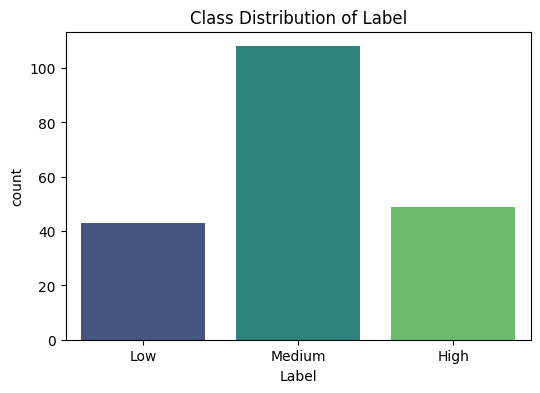

In [16]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Label', order=['Low', 'Medium', 'High'],palette='viridis')
plt.title('Class Distribution of Label')
plt.show()

In [17]:
df['Label'].value_counts()

Label
Medium    108
High       49
Low        43
Name: count, dtype: int64

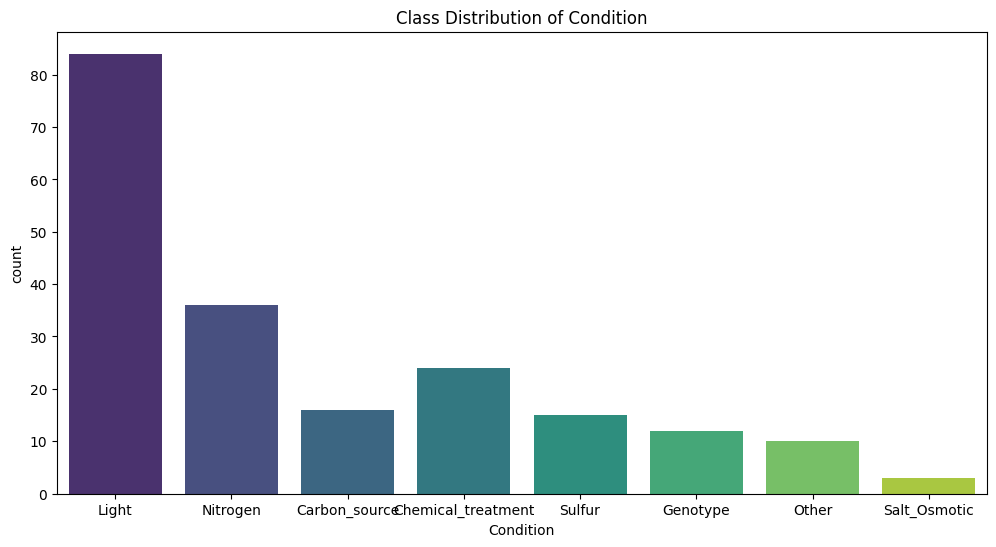

In [18]:
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='Condition', order=['Light', 'Nitrogen', 'Carbon_source','Chemical_treatment','Sulfur','Genotype','Other','Salt_Osmotic'],palette='viridis')
plt.title('Class Distribution of Condition')
plt.show()

#### Box Plot

พบยีนทั้งหมด 7 ตัว ได้แก่: ['BKT_TPM', 'crtZ_TPM', 'crtW_TPM', 'PDS_TPM', 'ZDS_TPM', 'lcyB_TPM', 'crtB_TPM']


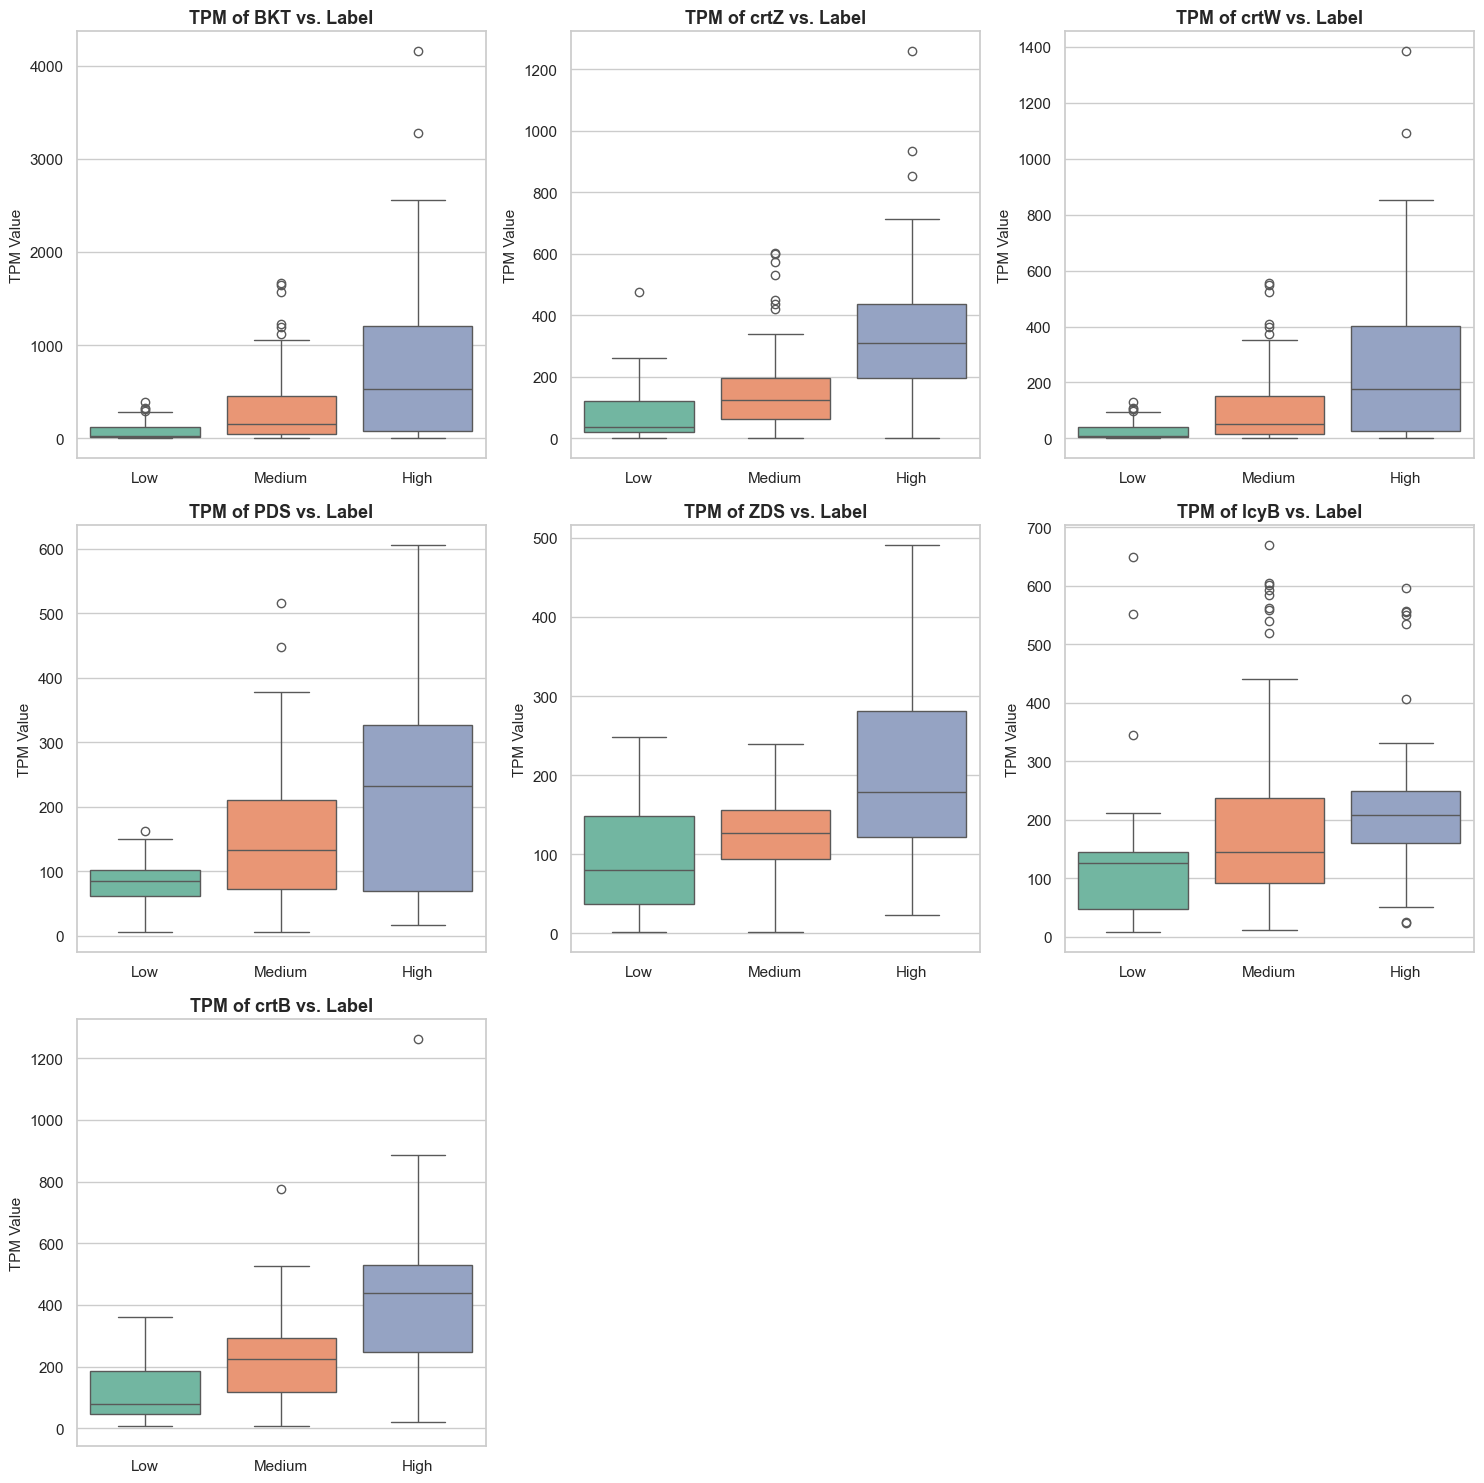

In [19]:
import math
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

tpm_cols = [col for col in df.columns if '_TPM' in col]
num_genes = len(tpm_cols)

print(f"พบยีนทั้งหมด {num_genes} ตัว ได้แก่: {tpm_cols}")


cols_per_row = 3
rows = math.ceil(num_genes / cols_per_row)


fig, axes = plt.subplots(rows, cols_per_row, figsize=(15, 5 * rows))

axes = axes.flatten()


for i, col_name in enumerate(tpm_cols):
    # วาด Boxplot ลงในช่องที่ i
    sns.boxplot(
        data=df, 
        x='Label', 
        y=col_name, 
        order=['Low', 'Medium', 'High'], 
        ax=axes[i], 
        palette='Set2' # เปลี่ยนสีได้ เช่น 'Set3', 'viridis', 'coolwarm'
    )
    
    # ตัดคำว่า '_TPM' ออกจากชื่อบนหัวกราฟเพื่อความสวยงาม
    gene_name = col_name.replace('_TPM', '')
    
    # ตั้งชื่อหัวกราฟและแกน Y
    axes[i].set_title(f'TPM of {gene_name} vs. Label', fontsize=13, fontweight='bold')
    axes[i].set_ylabel('TPM Value', fontsize=11)
    axes[i].set_xlabel('')


for j in range(num_genes, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

#### Heat Map shows relation between each gene expression

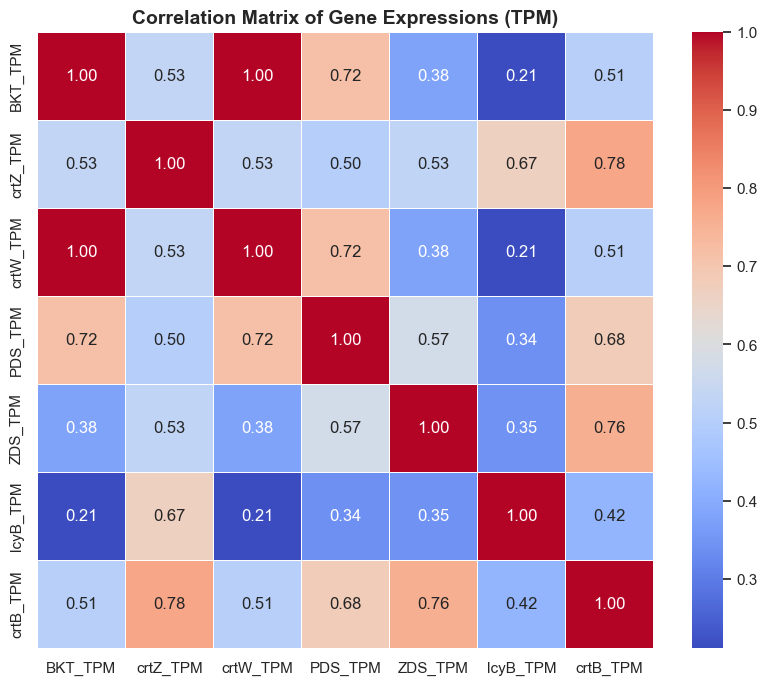

In [20]:
# เลือกเฉพาะคอลัมน์ที่ลงท้ายด้วย _TPM
tpm_cols = [col for col in df.columns if '_TPM' in col]

plt.figure(figsize=(10, 8))
corr_matrix = df[tpm_cols].corr()
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', square=True, linewidths=0.5)
plt.title('Correlation Matrix of Gene Expressions (TPM)', fontsize=14, fontweight='bold')
plt.show()

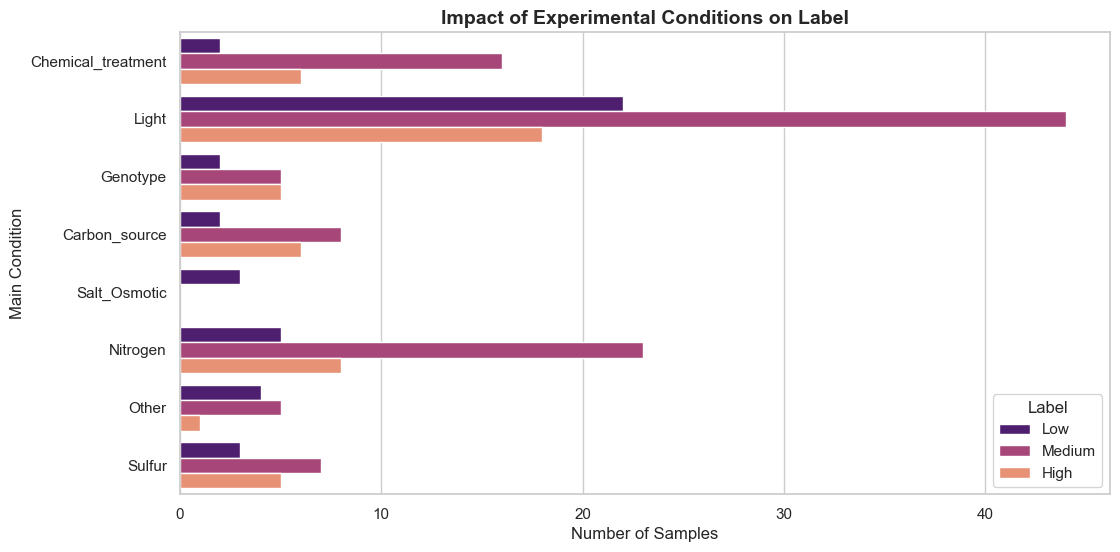

In [21]:
plt.figure(figsize=(12, 6))
sns.countplot(data=df, y='Condition', hue='Label', hue_order=['Low', 'Medium', 'High'], palette='magma')
plt.title('Impact of Experimental Conditions on Label', fontsize=14, fontweight='bold')
plt.xlabel('Number of Samples')
plt.ylabel('Main Condition')
plt.legend(title='Label', loc='lower right')
plt.show()

# Data Preprocessing

## 1.Feature Selection

In [22]:
# Define the target column
target_col = 'Label'
# Delete unnecessary columns
#cols_to_drop = ['Strain']
#df = df.drop(columns=cols_to_drop)

X = df

In [23]:
#Drop corelated features
X = X.drop(['BKT_TPM'], axis=1)

In [24]:
X.shape

(200, 17)

In [25]:
# Drop adundant features
X = X.drop(['Species','BKT','crtZ','crtW','PDS','ZDS','crtB','lcyB'], axis=1)

## 2.Seperate taget columns

In [26]:
#Separate X and Y
X = X.drop(columns=[target_col])
Y = df[target_col]

In [27]:
X.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Condition  200 non-null    str    
 1   Compound   200 non-null    str    
 2   crtZ_TPM   200 non-null    float64
 3   crtW_TPM   200 non-null    float64
 4   PDS_TPM    200 non-null    float64
 5   ZDS_TPM    200 non-null    float64
 6   lcyB_TPM   200 non-null    float64
 7   crtB_TPM   200 non-null    float64
dtypes: float64(6), str(2)
memory usage: 16.4 KB


## 3. Encoding

### One-Hot Encoding

In [28]:
X_encoded = pd.get_dummies(X, drop_first=True)

In [29]:
X_encoded.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   crtZ_TPM                      200 non-null    float64
 1   crtW_TPM                      200 non-null    float64
 2   PDS_TPM                       200 non-null    float64
 3   ZDS_TPM                       200 non-null    float64
 4   lcyB_TPM                      200 non-null    float64
 5   crtB_TPM                      200 non-null    float64
 6   Condition_Chemical_treatment  200 non-null    bool   
 7   Condition_Genotype            200 non-null    bool   
 8   Condition_Light               200 non-null    bool   
 9   Condition_Nitrogen            200 non-null    bool   
 10  Condition_Other               200 non-null    bool   
 11  Condition_Salt_Osmotic        200 non-null    bool   
 12  Condition_Sulfur              200 non-null    bool   
 13  Compound_astaxan

### Label Encoder

In [30]:
# To change Label(High,Medium,Low) to numerical values (0,1,2)
label_encoder = LabelEncoder()
Y_encoded = label_encoder.fit_transform(Y)

print(f"Label classes: {label_encoder.classes_}")
print(f"Encoded labels: {np.unique(Y_encoded)}")

Label classes: ['High' 'Low' 'Medium']
Encoded labels: [0 1 2]


## 4.Train Test split

In [31]:
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, Y_encoded, test_size=0.2, random_state=42, stratify=Y_encoded
)

## 5. Data scaling

In [32]:
# Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"X_train shape: {X_train_scaled.shape}, X_test shape: {X_test_scaled.shape}")

X_train shape: (160, 14), X_test shape: (40, 14)


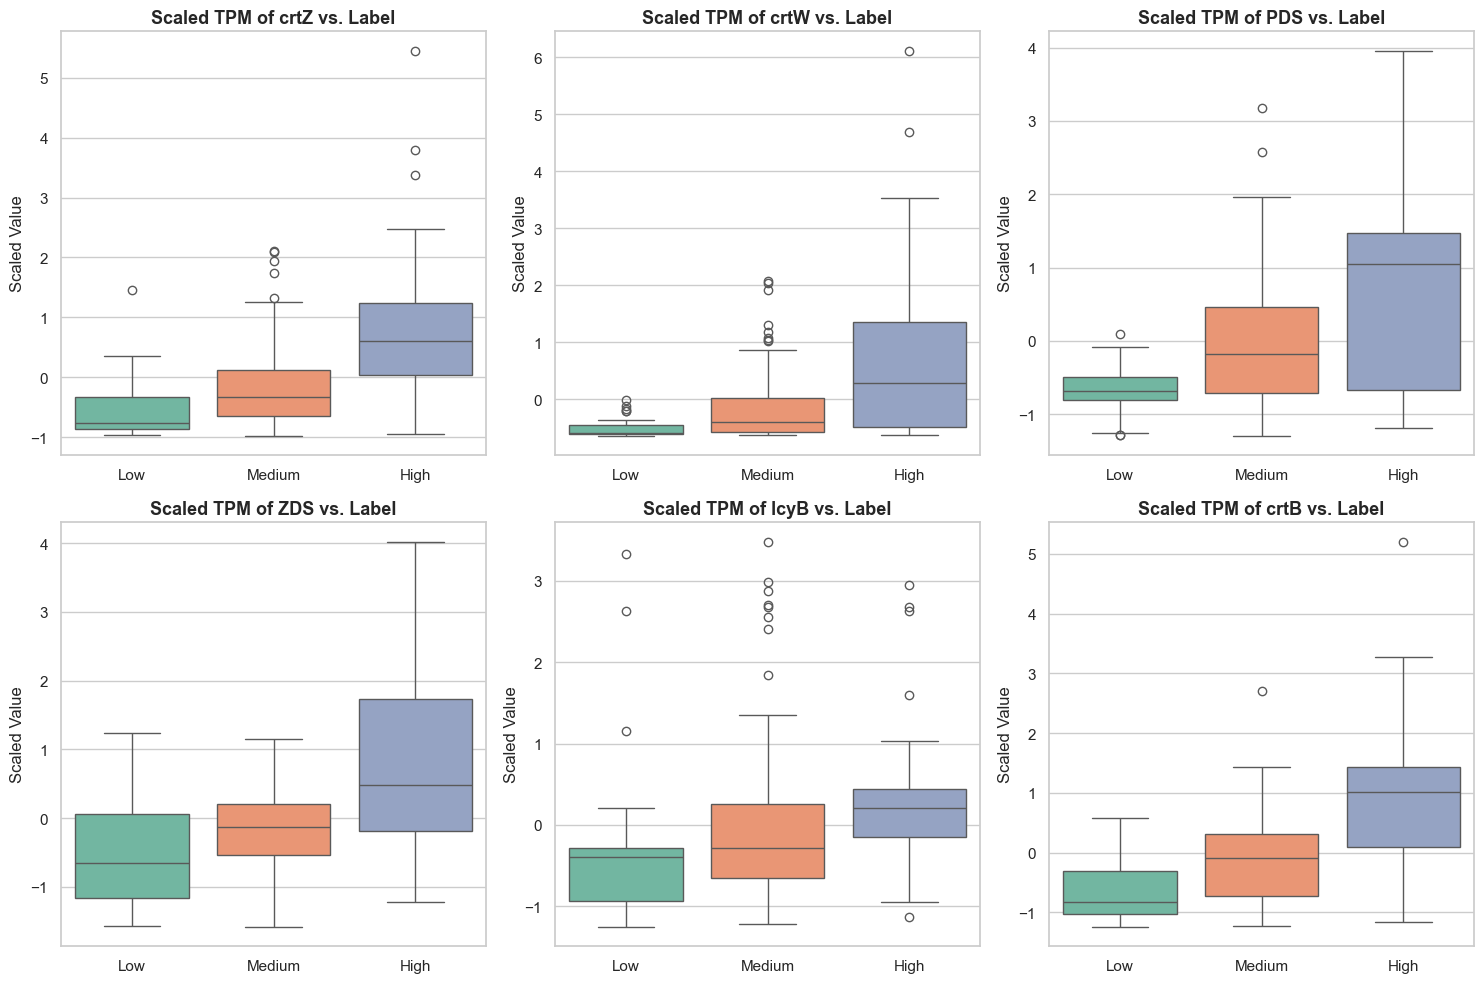

In [33]:
import math
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

sns.set_theme(style="whitegrid")

# Rebuild DataFrame with column names from the scaled numpy array
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_encoded.columns, index=X_train.index)
X_train_scaled_df['Label'] = y_train

# Select only TPM columns
tpm_cols = [col for col in X_encoded.columns if '_TPM' in col]
num_genes = len(tpm_cols)

cols_per_row = 3
rows = math.ceil(num_genes / cols_per_row)

fig, axes = plt.subplots(rows, cols_per_row, figsize=(15, 5 * rows))
axes = axes.flatten()

label_map = {0: 'High', 1: 'Low', 2: 'Medium'}  # from LabelEncoder alphabetical order
X_train_scaled_df['Label_name'] = X_train_scaled_df['Label'].map(label_map)

for i, col_name in enumerate(tpm_cols):
    sns.boxplot(
        data=X_train_scaled_df,
        x='Label_name',
        y=col_name,
        order=['Low', 'Medium', 'High'],
        ax=axes[i],
        palette='Set2'
    )
    gene_name = col_name.replace('_TPM', '')
    axes[i].set_title(f'Scaled TPM of {gene_name} vs. Label', fontsize=13, fontweight='bold')
    axes[i].set_ylabel('Scaled Value')
    axes[i].set_xlabel('')

for j in range(num_genes, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [34]:
from sklearn.preprocessing import RobustScaler

robust_scaler = RobustScaler()
X_train_robust = robust_scaler.fit_transform(X_train)
X_test_robust = robust_scaler.transform(X_test)

In [35]:
print(f"X_train shape: {X_train_robust.shape}, X_test shape: {X_test_robust.shape}")

X_train shape: (160, 14), X_test shape: (40, 14)


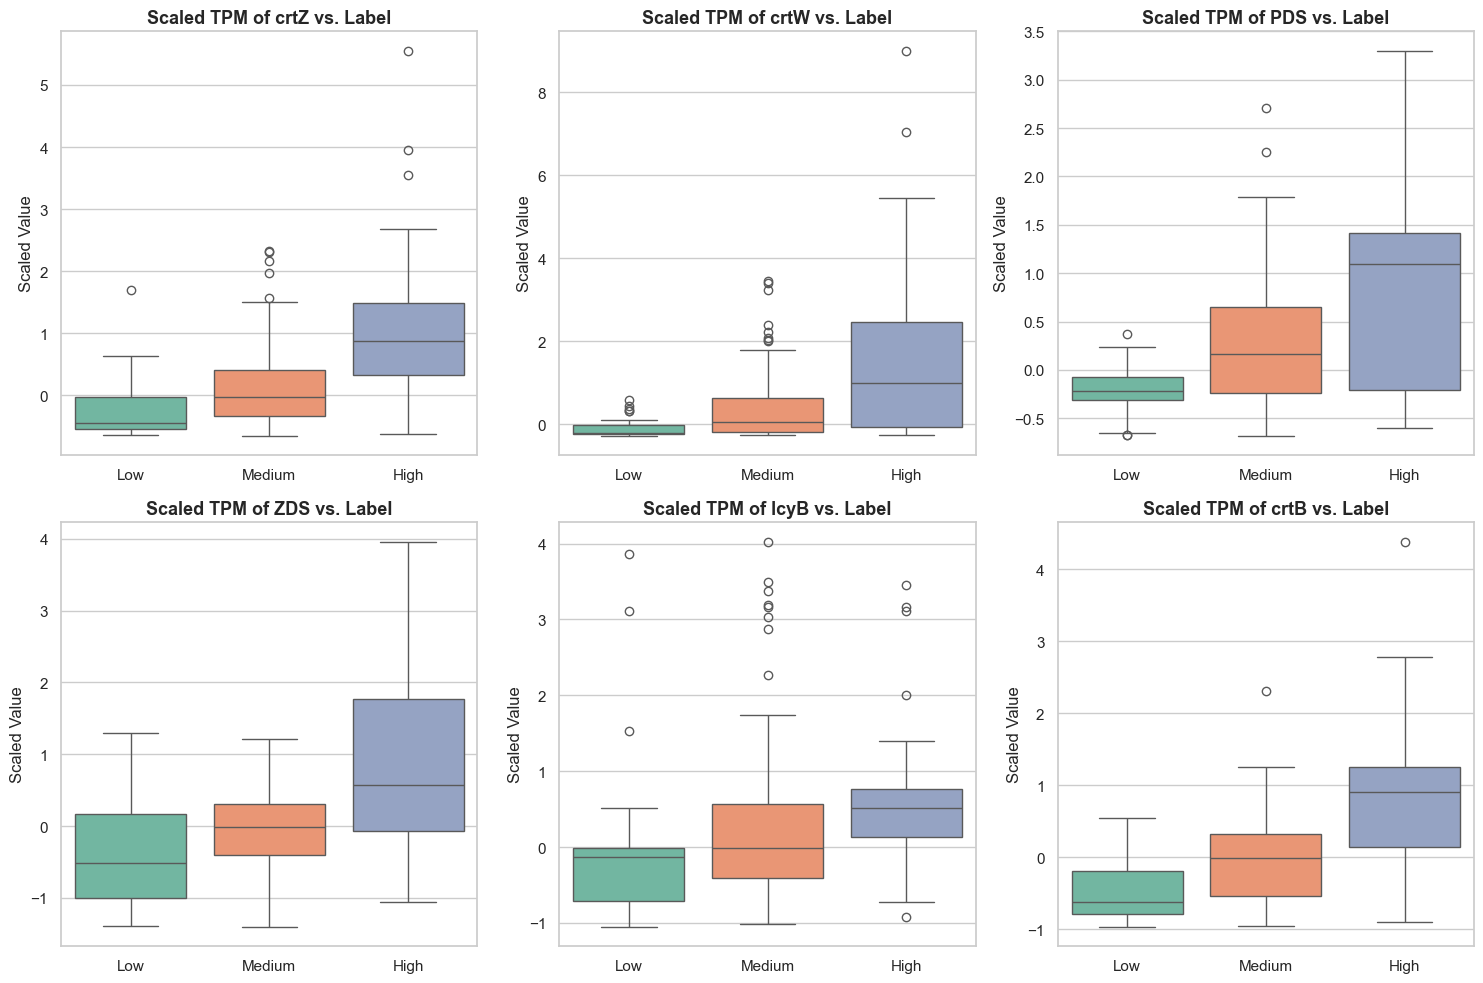

In [36]:
import math
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

sns.set_theme(style="whitegrid")

# Rebuild DataFrame with column names from the scaled numpy array
X_train_robust_df = pd.DataFrame(X_train_robust, columns=X_encoded.columns, index=X_train.index)
X_train_robust_df['Label'] = y_train

# Select only TPM columns
tpm_cols = [col for col in X_encoded.columns if '_TPM' in col]
num_genes = len(tpm_cols)

cols_per_row = 3
rows = math.ceil(num_genes / cols_per_row)

fig, axes = plt.subplots(rows, cols_per_row, figsize=(15, 5 * rows))
axes = axes.flatten()

label_map = {0: 'High', 1: 'Low', 2: 'Medium'}  # from LabelEncoder alphabetical order
X_train_robust_df['Label_name'] = X_train_robust_df['Label'].map(label_map)

for i, col_name in enumerate(tpm_cols):
    sns.boxplot(
        data=X_train_robust_df,
        x='Label_name',
        y=col_name,
        order=['Low', 'Medium', 'High'],
        ax=axes[i],
        palette='Set2'
    )
    gene_name = col_name.replace('_TPM', '')
    axes[i].set_title(f'Scaled TPM of {gene_name} vs. Label', fontsize=13, fontweight='bold')
    axes[i].set_ylabel('Scaled Value')
    axes[i].set_xlabel('')

for j in range(num_genes, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

# Model

## Import Model

In [37]:
# Model training for multiple classifiers: LogisticRegression, QDA, KNN, ANN, SVC, RandomForest, XGBoost
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC    # ->SVM
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import cross_val_score

# Keras / TensorFlow for ANN
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping

## Model Trainning

In [38]:
# reproducibility
np.random.seed(42)
tf.random.set_seed(42)


n_classes = len(np.unique(y_train))

results = {}

### Logistic Regression

In [39]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Base logistic regression (multiclass)
lr = LogisticRegression(random_state=42)

# Parameter grid with solver-safe combinations
param_grid = [
    {
        'solver': ['lbfgs', 'newton-cg', 'sag'],
        'penalty': ['l2'],
        'C': [0.001, 0.01, 0.1, 1, 10, 100],
        'multi_class': ['multinomial'],
        'max_iter': [1000]
    },
    {
        'solver': ['liblinear', 'saga'],
        'penalty': ['l1', 'l2'],
        'C': [0.001, 0.01, 0.1, 1, 10],
        'multi_class': ['ovr'],
        'max_iter': [1000]
    }
]

# Grid search
lr_grid = GridSearchCV(lr, param_grid, cv=5, scoring='accuracy', n_jobs=-1, verbose=1)
lr_grid.fit(X_train_robust, y_train)

best_lr = lr_grid.best_estimator_
print("Best params:", lr_grid.best_params_)
print("Best CV score:", lr_grid.best_score_)

# Test evaluation
y_pred = best_lr.predict(X_test_robust)
print("Test Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

# Optional: cross-validated scores on training set
cv_scores = cross_val_score(best_lr, X_train_robust, y_train, cv=3, scoring='accuracy', n_jobs=-1)
print("Train CV scores:", cv_scores)
print("Train CV mean:", cv_scores.mean())

results['LogisticRegression'] = {
    'model': best_lr,  # เก็บ best_lr ที่ผ่านการจูนแล้ว 
    'accuracy': accuracy_score(y_test, y_pred),
    'report': classification_report(y_test, y_pred, output_dict=True),
    'best_params': lr_grid.best_params_,  # เก็บพารามิเตอร์ที่ดีที่สุดไว้ดู
    'cv_mean_score': cv_scores.mean()     # เก็บค่า CV Score ไว้เปรียบเทียบ
}

# Example predictions from Logistic Regression
n_examples = 10

# Predict labels and probabilities on the test set
y_pred = best_lr.predict(X_test_robust)
y_proba = best_lr.predict_proba(X_test_robust)

# Convert encoded labels back to original class names
true_labels = label_encoder.inverse_transform(y_test)
pred_labels = label_encoder.inverse_transform(y_pred)

# Build a table of example predictions
example_results = X_test.iloc[:n_examples].copy()
example_results['Actual_Label'] = true_labels[:n_examples]
example_results['Predicted_Label'] = pred_labels[:n_examples]
example_results['Confidence'] = y_proba[:n_examples].max(axis=1)
example_results['Correct'] = example_results['Actual_Label'] == example_results['Predicted_Label']

print("Example prediction results from Logistic Regression:")
display(
    example_results[
        ['Actual_Label', 'Predicted_Label', 'Confidence', 'Correct']
    ]
)

# Optional: show one sample in more detail
sample_idx = 0
print("\nDetailed example:")
print("Actual label:", true_labels[sample_idx])
print("Predicted label:", pred_labels[sample_idx])
print("Class probabilities:")
for class_name, prob in zip(label_encoder.classes_, y_proba[sample_idx]):
    print(f"  {class_name}: {prob:.4f}")


Fitting 5 folds for each of 38 candidates, totalling 190 fits
Best params: {'C': 10, 'max_iter': 1000, 'multi_class': 'multinomial', 'penalty': 'l2', 'solver': 'lbfgs'}
Best CV score: 0.7625
Test Accuracy: 0.775

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.70      0.82        10
           1       0.67      0.67      0.67         9
           2       0.75      0.86      0.80        21

    accuracy                           0.78        40
   macro avg       0.81      0.74      0.76        40
weighted avg       0.79      0.78      0.78        40

Confusion Matrix:
 [[ 7  0  3]
 [ 0  6  3]
 [ 0  3 18]]
Train CV scores: [0.74074074 0.79245283 0.71698113]
Train CV mean: 0.7500582343349639
Example prediction results from Logistic Regression:


,Actual_Label,Predicted_Label,Confidence,Correct
129,High,High,0.717409,True
4,Medium,Medium,0.974556,True
83,High,Medium,0.540611,False
113,Low,Low,0.750893,True
117,Medium,Medium,0.903245,True
162,Medium,Medium,0.578842,True
9,Medium,Medium,0.834614,True
187,Medium,Medium,0.595938,True
144,Medium,Medium,0.682749,True
12,Medium,Medium,0.979681,True



Detailed example:
Actual label: High
Predicted label: High
Class probabilities:
  High: 0.7174
  Low: 0.0003
  Medium: 0.2823


### SVM

In [40]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Define base SVC and hyperparameter grid
svc = SVC(probability=True, random_state=42)
param_grid = {
    'kernel': ['rbf', 'linear', 'poly'],
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 'auto', 0.01, 0.001]
}

# Grid search with 5-fold CV
svc_grid = GridSearchCV(svc, param_grid, cv=3, scoring='accuracy', n_jobs=-1, verbose=1)
svc_grid.fit(X_train_robust, y_train)

# Best estimator and CV score
best_svc = svc_grid.best_estimator_
print("Best params:", svc_grid.best_params_)
print("Best CV score:", svc_grid.best_score_)

# Evaluate on test set
y_pred = best_svc.predict(X_test_robust)
print("Test Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

# Optional: cross-validated scores on training set
cv_scores = cross_val_score(best_svc, X_train_robust, y_train, cv=3, scoring='accuracy', n_jobs=-1)
print("Train CV scores:", cv_scores)
print("Train CV mean:", cv_scores.mean())

results['SVC'] = {
    'model': best_svc,  # เก็บ best_svc ที่ผ่านการจูนแล้ว 
    'accuracy': accuracy_score(y_test, y_pred),
    'report': classification_report(y_test, y_pred, output_dict=True),
    'best_params': svc_grid.best_params_,  # เก็บพารามิเตอร์ที่ดีที่สุดไว้ดู
    'cv_mean_score': cv_scores.mean()     # เก็บค่า CV Score ไว้เปรียบเทียบ
}

# Example predictions from SVC
n_examples = 10

# Predict labels and probabilities on the test set
y_pred = best_svc.predict(X_test_robust)
y_proba = best_svc.predict_proba(X_test_robust)

# Convert encoded labels back to original class names
true_labels = label_encoder.inverse_transform(y_test)
pred_labels = label_encoder.inverse_transform(y_pred)

# Build a table of example predictions
example_results = X_test.iloc[:n_examples].copy()
example_results['Actual_Label'] = true_labels[:n_examples]
example_results['Predicted_Label'] = pred_labels[:n_examples]
example_results['Confidence'] = y_proba[:n_examples].max(axis=1)
example_results['Correct'] = example_results['Actual_Label'] == example_results['Predicted_Label']

print("Example prediction results from SVC:")
display(
    example_results[
        ['Actual_Label', 'Predicted_Label', 'Confidence', 'Correct']
    ]
)

# Optional: show one sample in more detail
sample_idx = 0
print("\nDetailed example:")
print("Actual label:", true_labels[sample_idx])
print("Predicted label:", pred_labels[sample_idx])
print("Class probabilities:")
for class_name, prob in zip(label_encoder.classes_, y_proba[sample_idx]):
    print(f"  {class_name}: {prob:.4f}")

Fitting 3 folds for each of 48 candidates, totalling 144 fits
Best params: {'C': 1, 'gamma': 'scale', 'kernel': 'linear'}
Best CV score: 0.7689261588632658
Test Accuracy: 0.75

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.60      0.75        10
           1       0.71      0.56      0.62         9
           2       0.70      0.90      0.79        21

    accuracy                           0.75        40
   macro avg       0.81      0.69      0.72        40
weighted avg       0.78      0.75      0.74        40

Confusion Matrix:
 [[ 6  0  4]
 [ 0  5  4]
 [ 0  2 19]]
Train CV scores: [0.74074074 0.75471698 0.81132075]
Train CV mean: 0.7689261588632658
Example prediction results from SVC:


,Actual_Label,Predicted_Label,Confidence,Correct
129,High,Medium,0.535432,False
4,Medium,Medium,0.832295,True
83,High,Medium,0.728029,False
113,Low,Low,0.741428,True
117,Medium,Medium,0.709336,True
162,Medium,Medium,0.518912,True
9,Medium,Medium,0.673357,True
187,Medium,Medium,0.614628,True
144,Medium,Medium,0.650515,True
12,Medium,Medium,0.847640,True



Detailed example:
Actual label: High
Predicted label: Medium
Class probabilities:
  High: 0.4340
  Low: 0.0306
  Medium: 0.5354


### QDA

In [41]:
# ...existing code...
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Base QDA
qda = QuadraticDiscriminantAnalysis()

# Parameter grid (regularization + optional covariance storage / tolerance)
param_grid = {
    'reg_param': [0.0, 0.001, 0.01, 0.1, 0.5],
    'store_covariance': [False, True],
    'tol': [1e-4, 1e-3, 1e-2]
}

# Grid search with 5-fold CV
qda_grid = GridSearchCV(qda, param_grid, cv=3, scoring='accuracy', n_jobs=-1, verbose=1)
qda_grid.fit(X_train_robust, y_train)

best_qda = qda_grid.best_estimator_
print("Best params:", qda_grid.best_params_)
print("Best CV score:", qda_grid.best_score_)

# Evaluate on test set
y_pred = best_qda.predict(X_test_robust)
print("Test Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

# Optional: cross-validated scores on training set
cv_scores = cross_val_score(best_qda, X_train_robust, y_train, cv=3, scoring='accuracy', n_jobs=-1)
print("Train CV scores:", cv_scores)
print("Train CV mean:", cv_scores.mean())

results['QDA'] = {
    'model': best_qda,  # เก็บ best_qda ที่ผ่านการจูนแล้ว 
    'accuracy': accuracy_score(y_test, y_pred),
    'report': classification_report(y_test, y_pred, output_dict=True),
    'best_params': qda_grid.best_params_,  # เก็บพารามิเตอร์ที่ดีที่สุดไว้ดู
    'cv_mean_score': cv_scores.mean()     # เก็บค่า CV Score ไว้เปรียบเทียบ
}

# Example predictions from QDA
n_examples = 10

# Predict labels and probabilities on the test set
y_pred = best_qda.predict(X_test_robust)
y_proba = best_qda.predict_proba(X_test_robust)

# Convert encoded labels back to original class names
true_labels = label_encoder.inverse_transform(y_test)
pred_labels = label_encoder.inverse_transform(y_pred)

# Build a table of example predictions
example_results = X_test.iloc[:n_examples].copy()
example_results['Actual_Label'] = true_labels[:n_examples]
example_results['Predicted_Label'] = pred_labels[:n_examples]
example_results['Confidence'] = y_proba[:n_examples].max(axis=1)
example_results['Correct'] = example_results['Actual_Label'] == example_results['Predicted_Label']

print("Example prediction results from QDA:")
display(
    example_results[
        ['Actual_Label', 'Predicted_Label', 'Confidence', 'Correct']
    ]
)

# Optional: show one sample in more detail
sample_idx = 0
print("\nDetailed example:")
print("Actual label:", true_labels[sample_idx])
print("Predicted label:", pred_labels[sample_idx])
print("Class probabilities:")
for class_name, prob in zip(label_encoder.classes_, y_proba[sample_idx]):
    print(f"  {class_name}: {prob:.4f}")

Fitting 3 folds for each of 30 candidates, totalling 90 fits
Best params: {'reg_param': 0.1, 'store_covariance': False, 'tol': 0.0001}
Best CV score: 0.6625902632191941
Test Accuracy: 0.625

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.50      0.67        10
           1       0.38      0.56      0.45         9
           2       0.68      0.71      0.70        21

    accuracy                           0.62        40
   macro avg       0.69      0.59      0.61        40
weighted avg       0.69      0.62      0.64        40

Confusion Matrix:
 [[ 5  2  3]
 [ 0  5  4]
 [ 0  6 15]]
Train CV scores: [0.64814815 0.56603774 0.77358491]
Train CV mean: 0.6625902632191941
Example prediction results from QDA:


,Actual_Label,Predicted_Label,Confidence,Correct
129,High,Medium,0.626144,False
4,Medium,Medium,0.992288,True
83,High,Medium,0.954298,False
113,Low,Low,0.984430,True
117,Medium,Low,0.511722,False
162,Medium,Medium,0.550490,True
9,Medium,Medium,0.948903,True
187,Medium,Medium,0.541624,True
144,Medium,Medium,0.612654,True
12,Medium,Medium,0.952135,True



Detailed example:
Actual label: High
Predicted label: Medium
Class probabilities:
  High: 0.3736
  Low: 0.0003
  Medium: 0.6261


### KNN

In [42]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Base KNN
knn = KNeighborsClassifier()

# Parameter grid
param_grid = {
    'n_neighbors': [3, 5, 7, 9, 11],
    'weights': ['uniform', 'distance'],
    'algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute'],
    'p': [1, 2]  # 1 = Manhattan, 2 = Euclidean
}

# Grid search with 5-fold CV
knn_grid = GridSearchCV(knn, param_grid, cv=3, scoring='accuracy', n_jobs=-1, verbose=1)
knn_grid.fit(X_train_robust, y_train)

best_knn = knn_grid.best_estimator_
print("Best params:", knn_grid.best_params_)
print("Best CV score:", knn_grid.best_score_)

# Evaluate on test set
y_pred = best_knn.predict(X_test_robust)
print("Test Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

# Optional: cross-validated scores on training set
cv_scores = cross_val_score(best_knn, X_train_robust, y_train, cv=3, scoring='accuracy', n_jobs=-1)
print("Train CV scores:", cv_scores)
print("Train CV mean:", cv_scores.mean())

results['KNN'] = {
    'model': best_knn,  # เก็บ best_knn ที่ผ่านการจูนแล้ว 
    'accuracy': accuracy_score(y_test, y_pred),
    'report': classification_report(y_test, y_pred, output_dict=True),
    'best_params': knn_grid.best_params_,  # เก็บพารามิเตอร์ที่ดีที่สุดไว้ดู
    'cv_mean_score': cv_scores.mean()     # เก็บค่า CV Score ไว้เปรียบเทียบ
}

# Example predictions from KNN
n_examples = 10

# Predict labels and probabilities on the test set
y_pred = best_knn.predict(X_test_robust)
y_proba = best_knn.predict_proba(X_test_robust)

# Convert encoded labels back to original class names
true_labels = label_encoder.inverse_transform(y_test)
pred_labels = label_encoder.inverse_transform(y_pred)

# Build a table of example predictions
example_results = X_test.iloc[:n_examples].copy()
example_results['Actual_Label'] = true_labels[:n_examples]
example_results['Predicted_Label'] = pred_labels[:n_examples]
example_results['Confidence'] = y_proba[:n_examples].max(axis=1)
example_results['Correct'] = example_results['Actual_Label'] == example_results['Predicted_Label']

print("Example prediction results from KNN:")
display(
    example_results[
        ['Actual_Label', 'Predicted_Label', 'Confidence', 'Correct']
    ]
)

# Optional: show one sample in more detail
sample_idx = 0
print("\nDetailed example:")
print("Actual label:", true_labels[sample_idx])
print("Predicted label:", pred_labels[sample_idx])
print("Class probabilities:")
for class_name, prob in zip(label_encoder.classes_, y_proba[sample_idx]):
    print(f"  {class_name}: {prob:.4f}")

Fitting 3 folds for each of 80 candidates, totalling 240 fits
Best params: {'algorithm': 'auto', 'n_neighbors': 3, 'p': 2, 'weights': 'distance'}
Best CV score: 0.7685767528534825
Test Accuracy: 0.8

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.70      0.82        10
           1       1.00      0.44      0.62         9
           2       0.72      1.00      0.84        21

    accuracy                           0.80        40
   macro avg       0.91      0.71      0.76        40
weighted avg       0.86      0.80      0.79        40

Confusion Matrix:
 [[ 7  0  3]
 [ 0  4  5]
 [ 0  0 21]]
Train CV scores: [0.7962963  0.75471698 0.75471698]
Train CV mean: 0.7685767528534825
Example prediction results from KNN:


,Actual_Label,Predicted_Label,Confidence,Correct
129,High,High,0.671650,True
4,Medium,Medium,1.000000,True
83,High,Medium,1.000000,False
113,Low,Low,1.000000,True
117,Medium,Medium,1.000000,True
162,Medium,Medium,0.770233,True
9,Medium,Medium,0.543087,True
187,Medium,Medium,0.719088,True
144,Medium,Medium,1.000000,True
12,Medium,Medium,1.000000,True



Detailed example:
Actual label: High
Predicted label: High
Class probabilities:
  High: 0.6716
  Low: 0.0000
  Medium: 0.3284


### Random Forest

In [43]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Base Random Forest
rf = RandomForestClassifier(random_state=42)

# Parameter grid
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7, 10],
    'min_samples_split': [10, 20, 30],
    'min_samples_leaf': [4, 8, 16],
    'max_features': ['sqrt', 'log2'],
    'bootstrap': [True]
}

# Grid search with 5-fold CV
rf_grid = GridSearchCV(rf, param_grid, cv=5, scoring='accuracy', n_jobs=-1, verbose=1)
rf_grid.fit(X_train_robust, y_train)

best_rf = rf_grid.best_estimator_
print("Best params:", rf_grid.best_params_)
print("Best CV score:", rf_grid.best_score_)

# Evaluate on test set
y_pred = best_rf.predict(X_test_robust)
print("Test Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

# Optional: cross-validated scores on training set
cv_scores = cross_val_score(best_rf, X_train_robust, y_train, cv=5, scoring='accuracy', n_jobs=-1)
print("Train CV scores:", cv_scores)
print("Train CV mean:", cv_scores.mean())

results['RandomForest'] = {
    'model': best_rf,  # เก็บ best_rf ที่ผ่านการจูนแล้ว 
    'accuracy': accuracy_score(y_test, y_pred),
    'report': classification_report(y_test, y_pred, output_dict=True),
    'best_params': rf_grid.best_params_,  # เก็บพารามิเตอร์ที่ดีที่สุดไว้ดู
    'cv_mean_score': cv_scores.mean()     # เก็บค่า CV Score ไว้เปรียบเทียบ
}

# Example predictions from Random Forest
n_examples = 10

# Predict labels and probabilities on the test set
y_pred = best_rf.predict(X_test_robust)
y_proba = best_rf.predict_proba(X_test_robust)

# Convert encoded labels back to original class names
true_labels = label_encoder.inverse_transform(y_test)
pred_labels = label_encoder.inverse_transform(y_pred)

# Build a table of example predictions
example_results = X_test.iloc[:n_examples].copy()
example_results['Actual_Label'] = true_labels[:n_examples]
example_results['Predicted_Label'] = pred_labels[:n_examples]
example_results['Confidence'] = y_proba[:n_examples].max(axis=1)
example_results['Correct'] = example_results['Actual_Label'] == example_results['Predicted_Label']

print("Example prediction results from Random Forest:")
display(
    example_results[
        ['Actual_Label', 'Predicted_Label', 'Confidence', 'Correct']
    ]
)

# Optional: show one sample in more detail
sample_idx = 0
print("\nDetailed example:")
print("Actual label:", true_labels[sample_idx])
print("Predicted label:", pred_labels[sample_idx])
print("Class probabilities:")
for class_name, prob in zip(label_encoder.classes_, y_proba[sample_idx]):
    print(f"  {class_name}: {prob:.4f}")

Fitting 5 folds for each of 216 candidates, totalling 1080 fits
Best params: {'bootstrap': True, 'max_depth': 7, 'max_features': 'sqrt', 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 100}
Best CV score: 0.725
Test Accuracy: 0.8

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.50      0.67        10
           1       1.00      0.67      0.80         9
           2       0.72      1.00      0.84        21

    accuracy                           0.80        40
   macro avg       0.91      0.72      0.77        40
weighted avg       0.86      0.80      0.79        40

Confusion Matrix:
 [[ 5  0  5]
 [ 0  6  3]
 [ 0  0 21]]
Train CV scores: [0.8125  0.5625  0.75    0.84375 0.65625]
Train CV mean: 0.725
Example prediction results from Random Forest:


,Actual_Label,Predicted_Label,Confidence,Correct
129,High,High,0.694932,True
4,Medium,Medium,0.765312,True
83,High,Medium,0.803510,False
113,Low,Low,0.653578,True
117,Medium,Medium,0.681850,True
162,Medium,Medium,0.813822,True
9,Medium,Medium,0.653598,True
187,Medium,Medium,0.599039,True
144,Medium,Medium,0.585775,True
12,Medium,Medium,0.779717,True



Detailed example:
Actual label: High
Predicted label: High
Class probabilities:
  High: 0.6949
  Low: 0.0186
  Medium: 0.2865


### XGBoost

In [44]:
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Base XGBoost (multiclass)
xgb = XGBClassifier(objective='multi:softprob', use_label_encoder=False,
                    eval_metric='mlogloss', random_state=42, n_jobs=-1)

# Parameter grid
param_grid = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5, 7],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'gamma': [0, 0.1, 0.5],
    'min_child_weight': [1, 3, 5]
}

# Grid search with 5-fold CV
xgb_grid = GridSearchCV(xgb, param_grid, cv=5, scoring='accuracy', n_jobs=-1, verbose=1)
xgb_grid.fit(X_train_robust, y_train)

best_xgb = xgb_grid.best_estimator_
print("Best params:", xgb_grid.best_params_)
print("Best CV score:", xgb_grid.best_score_)

# Evaluate on test set
y_pred = best_xgb.predict(X_test_robust)
print("Test Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

# Optional: cross-validated scores on training set
cv_scores = cross_val_score(best_xgb, X_train_robust, y_train, cv=5, scoring='accuracy', n_jobs=-1)
print("Train CV scores:", cv_scores)
print("Train CV mean:", cv_scores.mean())

results['XGBoost'] = {
    'model': best_xgb,  # เก็บ best_xgb ที่ผ่านการจูนแล้ว 
    'accuracy': accuracy_score(y_test, y_pred),
    'report': classification_report(y_test, y_pred, output_dict=True),
    'best_params': xgb_grid.best_params_,  # เก็บพารามิเตอร์ที่ดีที่สุดไว้ดู
    'cv_mean_score': cv_scores.mean()     # เก็บค่า CV Score ไว้เปรียบเทียบ
}

# Example predictions from XGBoost
n_examples = 10

# Predict labels and probabilities on the test set
y_pred = best_xgb.predict(X_test_robust)
y_proba = best_xgb.predict_proba(X_test_robust)

# Convert encoded labels back to original class names
true_labels = label_encoder.inverse_transform(y_test)
pred_labels = label_encoder.inverse_transform(y_pred)

# Build a table of example predictions
example_results = X_test.iloc[:n_examples].copy()
example_results['Actual_Label'] = true_labels[:n_examples]
example_results['Predicted_Label'] = pred_labels[:n_examples]
example_results['Confidence'] = y_proba[:n_examples].max(axis=1)
example_results['Correct'] = example_results['Actual_Label'] == example_results['Predicted_Label']

print("Example prediction results from XGBoost:")
display(
    example_results[
        ['Actual_Label', 'Predicted_Label', 'Confidence', 'Correct']
    ]
)

# Optional: show one sample in more detail
sample_idx = 0
print("\nDetailed example:")
print("Actual label:", true_labels[sample_idx])
print("Predicted label:", pred_labels[sample_idx])
print("Class probabilities:")
for class_name, prob in zip(label_encoder.classes_, y_proba[sample_idx]):
    print(f"  {class_name}: {prob:.4f}")

Fitting 5 folds for each of 2187 candidates, totalling 10935 fits
Best params: {'colsample_bytree': 0.6, 'gamma': 0, 'learning_rate': 0.05, 'max_depth': 3, 'min_child_weight': 1, 'n_estimators': 200, 'subsample': 0.8}
Best CV score: 0.7875
Test Accuracy: 0.85

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.70      0.82        10
           1       1.00      0.67      0.80         9
           2       0.78      1.00      0.88        21

    accuracy                           0.85        40
   macro avg       0.93      0.79      0.83        40
weighted avg       0.88      0.85      0.85        40

Confusion Matrix:
 [[ 7  0  3]
 [ 0  6  3]
 [ 0  0 21]]
Train CV scores: [0.875   0.625   0.8125  0.84375 0.78125]
Train CV mean: 0.7875
Example prediction results from XGBoost:


,Actual_Label,Predicted_Label,Confidence,Correct
129,High,High,0.887384,True
4,Medium,Medium,0.955291,True
83,High,Medium,0.905641,False
113,Low,Low,0.860101,True
117,Medium,Medium,0.882288,True
162,Medium,Medium,0.978114,True
9,Medium,Medium,0.820608,True
187,Medium,Medium,0.806051,True
144,Medium,Medium,0.813434,True
12,Medium,Medium,0.922971,True



Detailed example:
Actual label: High
Predicted label: High
Class probabilities:
  High: 0.8874
  Low: 0.0038
  Medium: 0.1088


### ANN

In [45]:
# ANN tuning with Keras Tuner (no scikit-learn GridSearchCV)
# Installs: pip install -U keras-tuner (run externally if needed)
try:
    import keras_tuner as kt
except Exception as e:
    raise ImportError("Please install keras-tuner: pip install -U keras-tuner")
import tensorflow as tf
from tensorflow import keras
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import numpy as np

def build_model(hp):
    units = hp.Choice('units', [16,32,64])
    dropout = hp.Choice('dropout', [0.3,0.4, 0.5])
    lr = hp.Choice('learning_rate', [1e-3, 5e-4])
    l2_reg = keras.regularizers.l2(0.01)
    model = keras.Sequential([
        keras.layers.Dense(units, activation='relu',kernel_regularizer=l2_reg ,input_shape=(X_train_robust.shape[1],)),
        keras.layers.Dropout(dropout),
        keras.layers.Dense(max(16, units//2), activation='relu', kernel_regularizer=l2_reg),
        keras.layers.Dropout(dropout/2),
        keras.layers.Dense(n_classes, activation='softmax')
    ])
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=lr),
                  loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

# Random search tuner (fast and simple)
tuner = kt.RandomSearch(build_model, objective='val_accuracy', max_trials=6,
                        executions_per_trial=1, directory='kt_dir', project_name='ann_tune')

es = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True)
tuner.search(X_train_robust, y_train, epochs=50, validation_split=0.1, callbacks=[es], verbose=1)

# Best hyperparameters and best validation (used here as CV proxy)
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]
best_trials = tuner.oracle.get_best_trials(num_trials=1)
best_val = None
if best_trials:
    try:
        best_val = best_trials[0].metrics.get_last_value('val_accuracy')
    except Exception:
        best_val = None

print("Best params:", {
    'units': best_hps.get('units'),
    'dropout': best_hps.get('dropout'),
    'learning_rate': best_hps.get('learning_rate')
})
print("Best CV score:", best_val)

# Build and fit best model on full training set
best_model = tuner.hypermodel.build(best_hps)
best_model.fit(X_train_robust, y_train, epochs=50, validation_split=0.1, callbacks=[es], verbose=0)

# Evaluate on test set
y_pred = np.argmax(best_model.predict(X_test_robust), axis=1)
print("Test Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

# Optional: manual cross-validated scores on training set (retrain per fold)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = []
for train_idx, val_idx in skf.split(X_train_robust, y_train):
    model = tuner.hypermodel.build(best_hps)
    model.fit(X_train_robust[train_idx], y_train[train_idx], epochs=50,
              validation_data=(X_train_robust[val_idx], y_train[val_idx]), callbacks=[es], verbose=0)
    preds = np.argmax(model.predict(X_train_robust[val_idx]), axis=1)
    cv_scores.append(accuracy_score(y_train[val_idx], preds))

print("Train CV scores:", cv_scores)
print("Train CV mean:", np.mean(cv_scores))

results['ANN'] = {
    'model': best_model,  # เก็บ best_model ที่ผ่านการจูนแล้ว 
    'accuracy': accuracy_score(y_test, y_pred),
    'report': classification_report(y_test, y_pred, output_dict=True),
    'best_params': {
        'units': best_hps.get('units'),
        'dropout': best_hps.get('dropout'),
        'learning_rate': best_hps.get('learning_rate')
    },  # เก็บพารามิเตอร์ที่ดีที่สุดไว้ดู
    'cv_mean_score': np.mean(cv_scores)     # เก็บค่า CV Score ไว้เปรียบเทียบ
}

# Example predictions from ANN
n_examples = 10

# Predict labels and probabilities on the test set
y_pred = np.argmax(best_model.predict(X_test_robust), axis=1)
y_proba = best_model.predict(X_test_robust)

# Convert encoded labels back to original class names
true_labels = label_encoder.inverse_transform(y_test)
pred_labels = label_encoder.inverse_transform(y_pred)

# Build a table of example predictions
example_results = X_test.iloc[:n_examples].copy()
example_results['Actual_Label'] = true_labels[:n_examples]
example_results['Predicted_Label'] = pred_labels[:n_examples]
example_results['Confidence'] = y_proba[:n_examples].max(axis=1)
example_results['Correct'] = example_results['Actual_Label'] == example_results['Predicted_Label']

print("Example prediction results from ANN:")
display(
    example_results[
         ['Actual_Label', 'Predicted_Label', 'Confidence', 'Correct']
    ]
)

# Optional: show one sample in more detail
sample_idx = 0
print("\nDetailed example:")
print("Actual label:", true_labels[sample_idx])
print("Predicted label:", pred_labels[sample_idx])
print("Class probabilities:")
for class_name, prob in zip(label_encoder.classes_, y_proba[sample_idx]):
    print(f"  {class_name}: {prob:.4f}")

Reloading Tuner from kt_dir\ann_tune\tuner0.json
Best params: {'units': 128, 'dropout': 0.2, 'learning_rate': 0.001}
Best CV score: 0.8571428656578064
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
Test Accuracy: 0.75

Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.70      0.78        10
           1       0.71      0.56      0.62         9
           2       0.72      0.86      0.78        21

    accuracy                           0.75        40
   macro avg       0.77      0.70      0.73        40
weighted avg       0.76      0.75      0.75        40

Confusion Matrix:
 [[ 7  0  3]
 [ 0  5  4]
 [ 1  2 18]]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
Train CV scores: [0.75, 0.71875, 0.65625, 0.78125, 0.75]
Train CV mean: 0.73125
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
2/2 ━━━━━━━━━━━━━━━━━

,Actual_Label,Predicted_Label,Confidence,Correct
129,High,High,0.783665,True
4,Medium,Medium,0.976404,True
83,High,Medium,0.779838,False
113,Low,Low,0.598717,True
117,Medium,Medium,0.768808,True
162,Medium,Medium,0.549592,True
9,Medium,Medium,0.877348,True
187,Medium,Medium,0.635818,True
144,Medium,Medium,0.604516,True
12,Medium,Medium,0.955752,True



Detailed example:
Actual label: High
Predicted label: High
Class probabilities:
  High: 0.7837
  Low: 0.0043
  Medium: 0.2120


In [46]:
best_model = build_model(best_hps)

# 2. Retrain the model and save the output to the 'history' variable
print("Retraining the best ANN model to generate learning curves...")
history = best_model.fit(
    X_train_robust, y_train,
    epochs=50,                  # You can adjust the number of epochs
    validation_split=0.2,       # Use 20% of training data for validation
    batch_size=16,
    verbose=1
)

Retraining the best ANN model to generate learning curves...
Epoch 1/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.4256 - loss: 2.1889 - val_accuracy: 0.6562 - val_loss: 1.9852
Epoch 2/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5141 - loss: 2.0277 - val_accuracy: 0.6875 - val_loss: 1.8927
Epoch 3/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6049 - loss: 1.8835 - val_accuracy: 0.6562 - val_loss: 1.7964
Epoch 4/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6151 - loss: 1.7888 - val_accuracy: 0.6562 - val_loss: 1.6953
Epoch 5/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6347 - loss: 1.6761 - val_accuracy: 0.6250 - val_loss: 1.6064
Epoch 6/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6512 - loss: 1.6316 - val_accuracy: 0.6875 - val_loss: 1.5329
Epoch 7/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6238 - loss: 1.5616 - val_accuracy: 0.6875 - val_loss: 1.4684
Epoch 8/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6806 - 

## Model Result

### Best model

In [47]:
# Print summary sorted by accuracy
summary = {name: info['accuracy'] for name, info in results.items()}
for name, acc in sorted(summary.items(), key=lambda x: x[1], reverse=True):
    print(f"{name}: {acc:.4f}")

# Example: detailed report for best model
best_name = max(summary, key=summary.get)
print(f"\nBest model: {best_name}\n")
import pprint
pprint.pprint(results[best_name]['report'])

XGBoost: 0.8500
KNN: 0.8000
RandomForest: 0.8000
LogisticRegression: 0.7750
SVC: 0.7500
ANN: 0.7500
QDA: 0.6250

Best model: XGBoost

{'0': {'f1-score': 0.8235294117647058,
       'precision': 1.0,
       'recall': 0.7,
       'support': 10.0},
 '1': {'f1-score': 0.8,
       'precision': 1.0,
       'recall': 0.6666666666666666,
       'support': 9.0},
 '2': {'f1-score': 0.875,
       'precision': 0.7777777777777778,
       'recall': 1.0,
       'support': 21.0},
 'accuracy': 0.85,
 'macro avg': {'f1-score': 0.832843137254902,
               'precision': 0.9259259259259259,
               'recall': 0.7888888888888889,
               'support': 40.0},
 'weighted avg': {'f1-score': 0.8452573529411765,
                  'precision': 0.8833333333333332,
                  'recall': 0.85,
                  'support': 40.0}}


### Accuracy and F1 score

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step


,model,accuracy,precision_macro,recall_macro,f1_macro
0,XGBoost,0.850,0.925926,0.788889,0.832843
1,KNN,0.800,0.908046,0.714815,0.759638
2,RandomForest,0.800,0.908046,0.722222,0.768889
3,LogisticRegression,0.775,0.805556,0.741270,0.763399
4,SVC,0.750,0.805996,0.686772,0.722222
5,QDA,0.625,0.688811,0.589947,0.606296
6,ANN,NaN,NaN,NaN,NaN


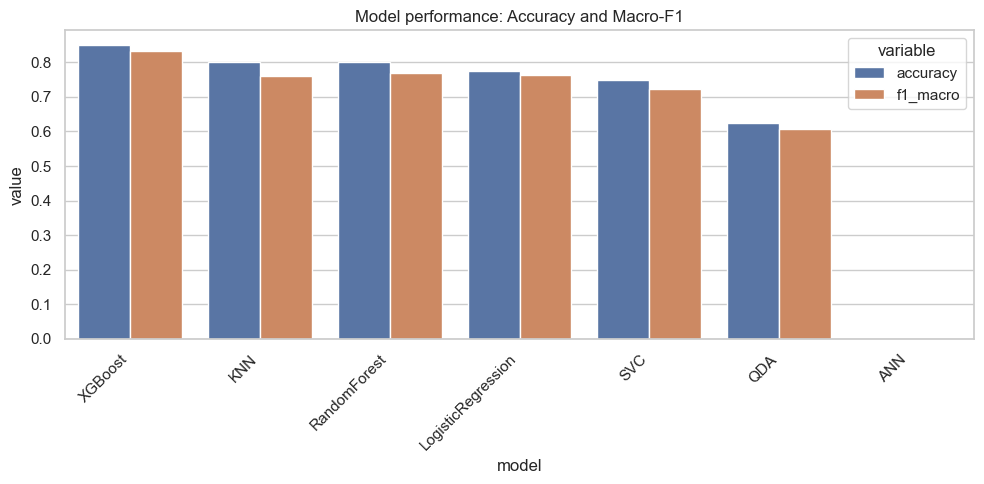

In [48]:
# Performance summary (accuracy + macro-F1 if available)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

# collect models
models = {}
for name, info in (results.items() if 'results' in globals() else {}):
    model = info['model'] if isinstance(info, dict) and 'model' in info else info
    models[name] = model

rows = []
for name, model in models.items():
    # choose test set
    X_test_use = globals().get('X_test_robust', globals().get('X_test'))
    y_test_use = globals().get('y_test')
    if X_test_use is None or y_test_use is None:
        continue
    try:
        y_pred = model.predict(X_test_use)
        acc = accuracy_score(y_test_use, y_pred)
        p = precision_score(y_test_use, y_pred, average='macro', zero_division=0)
        r = recall_score(y_test_use, y_pred, average='macro', zero_division=0)
        f1 = f1_score(y_test_use, y_pred, average='macro', zero_division=0)
    except Exception:
        acc = np.nan; p = np.nan; r = np.nan; f1 = np.nan
    rows.append({'model': name, 'accuracy': acc, 'precision_macro': p, 'recall_macro': r, 'f1_macro': f1})

perf_df = pd.DataFrame(rows).sort_values('accuracy', ascending=False).reset_index(drop=True)
display(perf_df)

# bar chart
plt.figure(figsize=(10,5))
sns.barplot(data=perf_df.melt(id_vars='model', value_vars=['accuracy','f1_macro']),
            x='model', y='value', hue='variable')
plt.xticks(rotation=45, ha='right')
plt.title('Model performance: Accuracy and Macro-F1')
plt.tight_layout()
plt.show()

### Confusion matrix

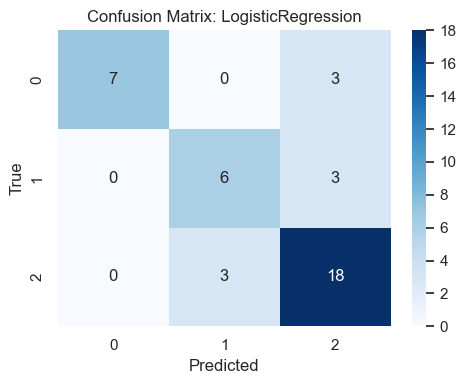

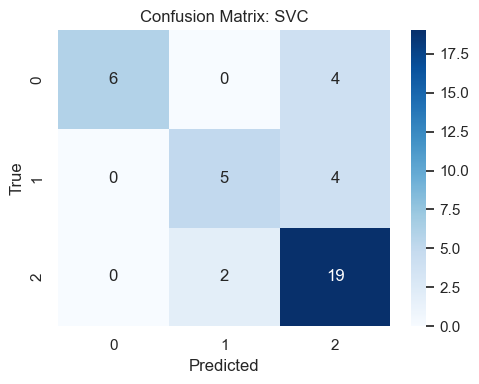

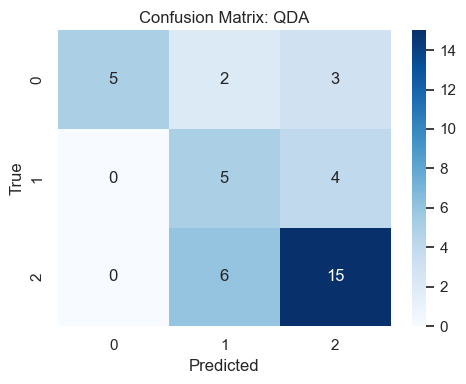

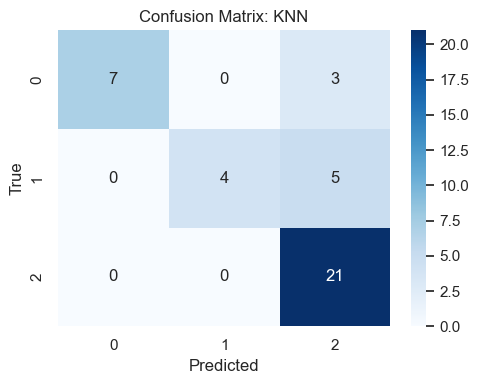

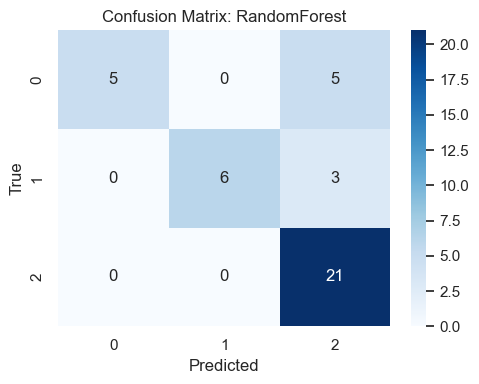

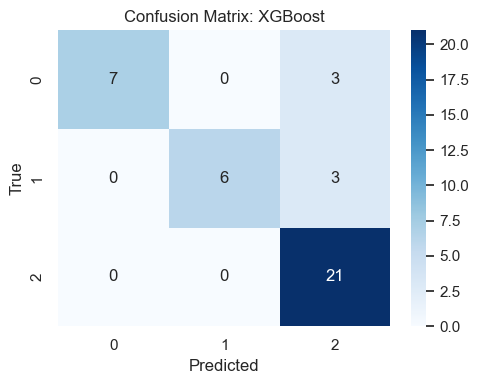

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
Skipping ANN: Classification metrics can't handle a mix of multiclass and continuous-multioutput targets


In [49]:
# Confusion matrices
from sklearn.metrics import confusion_matrix
import numpy as np

X_test_use = globals().get('X_test_robust', globals().get('X_test'))
y_test_use = globals().get('y_test')
if X_test_use is None or y_test_use is None:
    print("X_test / y_test not found in namespace.")
else:
    for name, model in models.items():
        try:
            y_pred = model.predict(X_test_use)
            cm = confusion_matrix(y_test_use, y_pred)
            plt.figure(figsize=(5,4))
            sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
            plt.title(f'Confusion Matrix: {name}')
            plt.xlabel('Predicted'); plt.ylabel('True')
            plt.tight_layout()
            plt.show()
        except Exception as e:
            print(f"Skipping {name}: {e}")

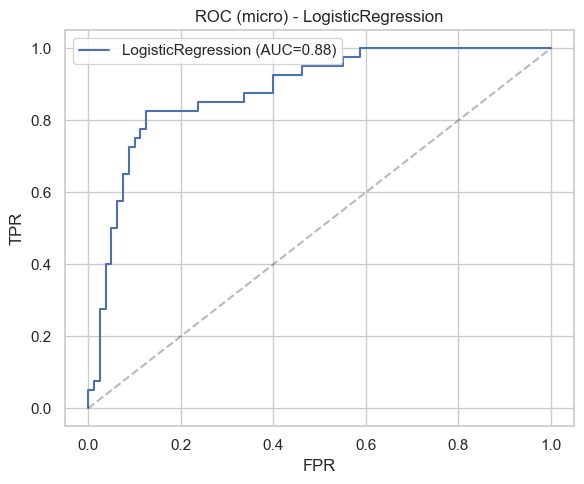

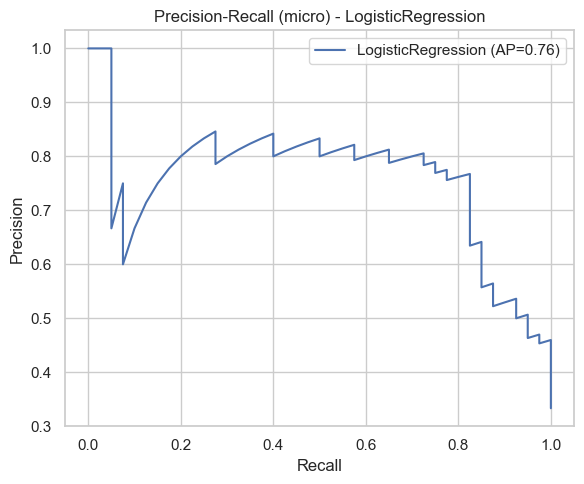

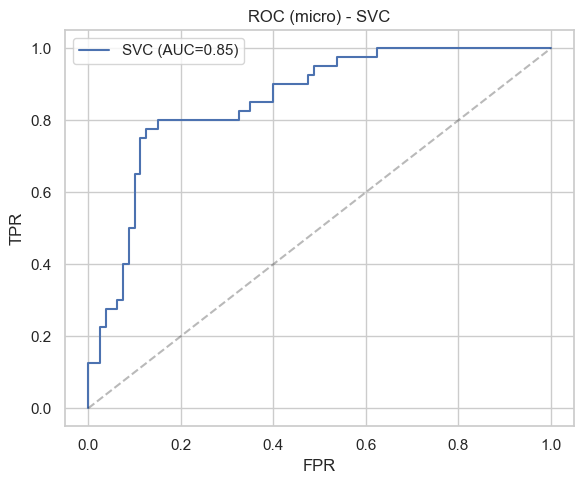

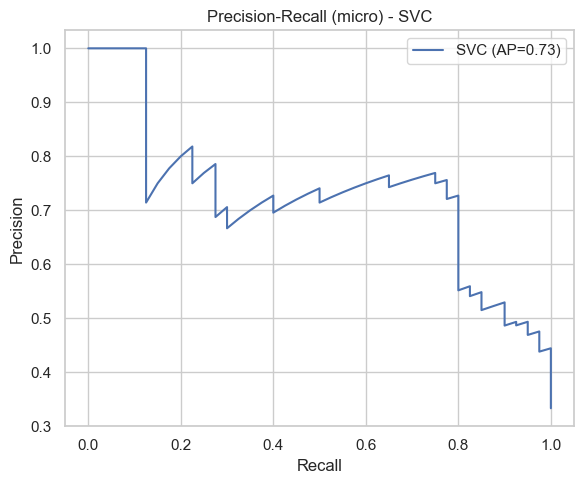

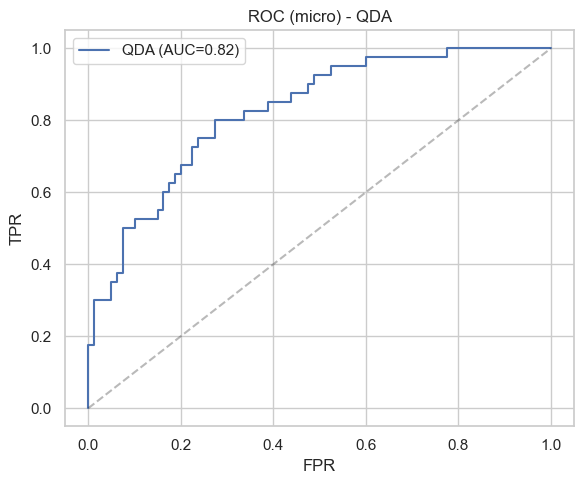

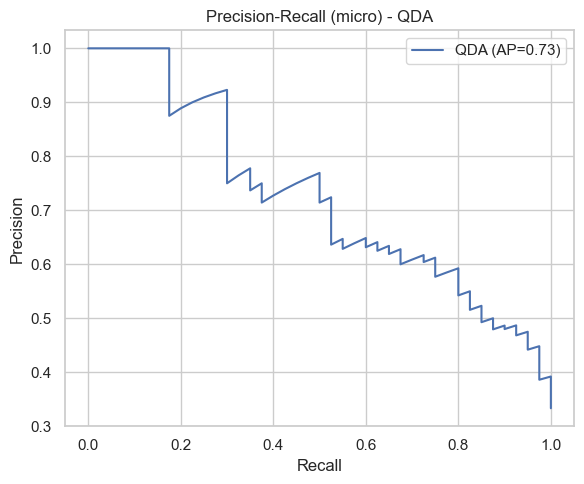

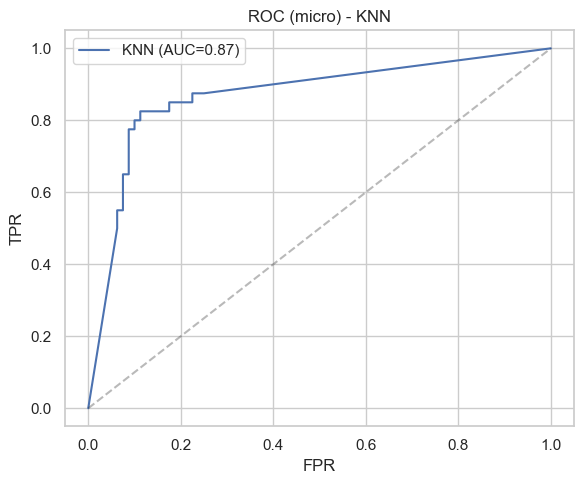

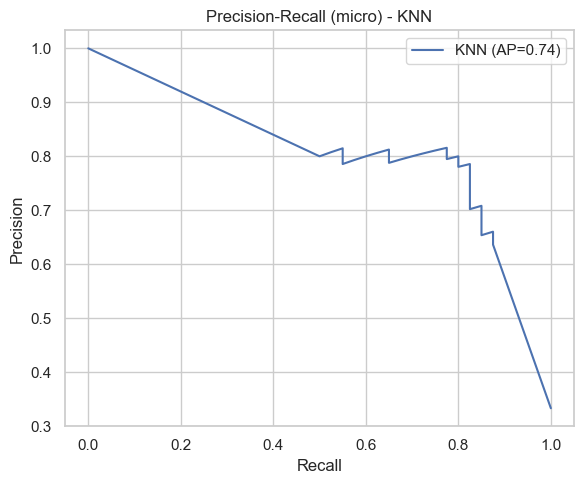

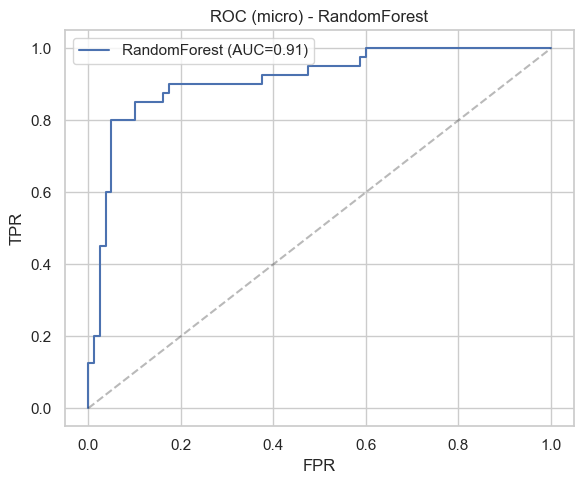

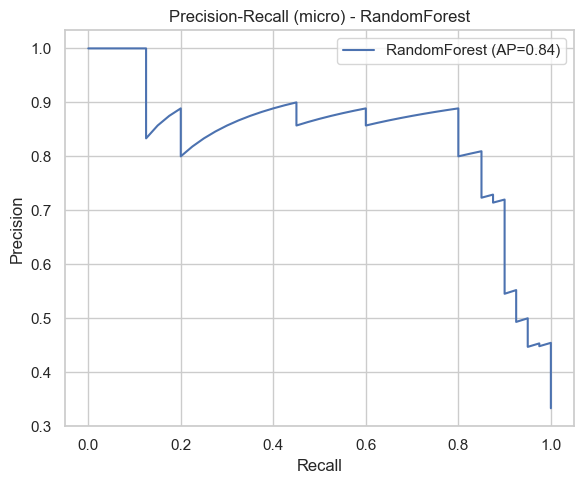

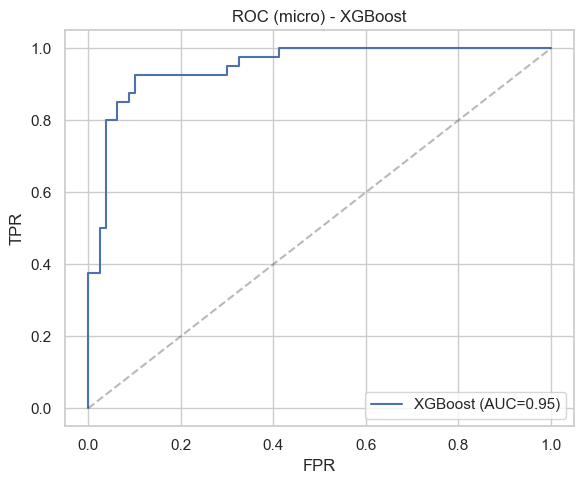

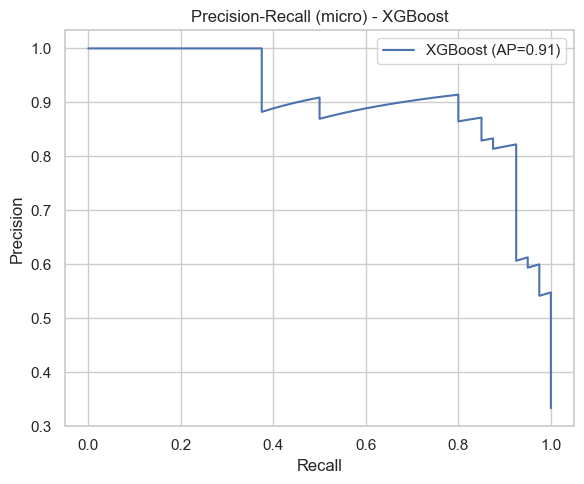

No prob/score for ANN, skipping ROC/PR.


In [50]:
# ROC & PR curves (multi-class micro-average). Requires predict_proba or decision_function.
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score
import numpy as np

X_test_use = globals().get('X_test_robust', globals().get('X_test'))
y_test_use = globals().get('y_test')
if X_test_use is None or y_test_use is None:
    print("X_test / y_test not found.")
else:
    classes = np.unique(y_test_use)
    y_bin = label_binarize(y_test_use, classes=classes)
    for name, model in models.items():
        try:
            if hasattr(model, 'predict_proba'):
                y_score = model.predict_proba(X_test_use)
            elif hasattr(model, 'decision_function'):
                y_score = model.decision_function(X_test_use)
            else:
                print(f"No prob/score for {name}, skipping ROC/PR.")
                continue
            # micro-average ROC
            fpr, tpr, _ = roc_curve(y_bin.ravel(), y_score.ravel())
            roc_auc = auc(fpr, tpr)
            plt.figure(figsize=(6,5))
            plt.plot(fpr, tpr, label=f'{name} (AUC={roc_auc:.2f})')
            plt.plot([0,1],[0,1],'k--', alpha=0.3)
            plt.xlabel('FPR'); plt.ylabel('TPR'); plt.title(f'ROC (micro) - {name}')
            plt.legend(); plt.tight_layout(); plt.show()

            # PR curve (micro)
            precision, recall, _ = precision_recall_curve(y_bin.ravel(), y_score.ravel())
            ap = average_precision_score(y_bin, y_score, average='micro')
            plt.figure(figsize=(6,5))
            plt.plot(recall, precision, label=f'{name} (AP={ap:.2f})')
            plt.xlabel('Recall'); plt.ylabel('Precision'); plt.title(f'Precision-Recall (micro) - {name}')
            plt.legend(); plt.tight_layout(); plt.show()
        except Exception as e:
            print(f"Error plotting ROC/PR for {name}: {e}")

### Learning Curve

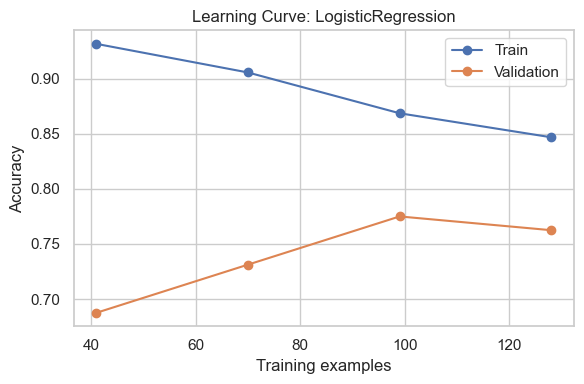

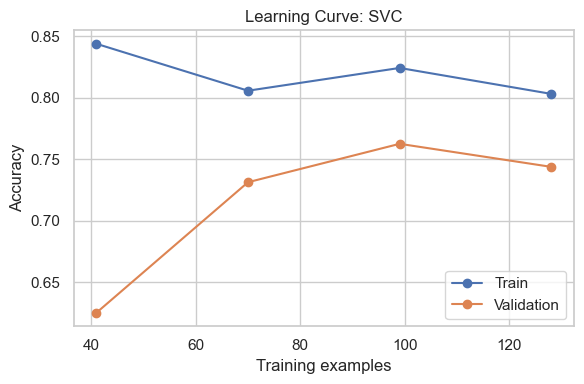

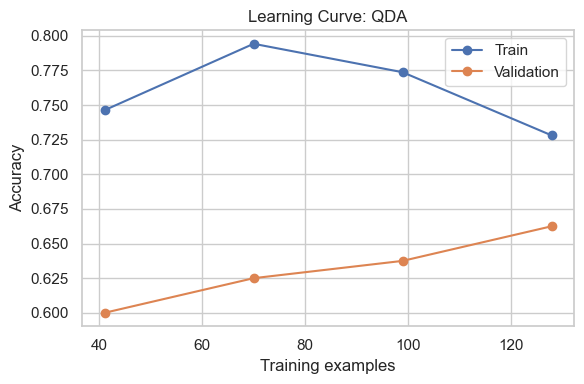

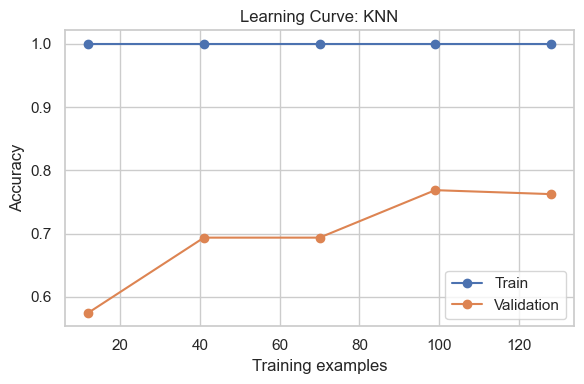

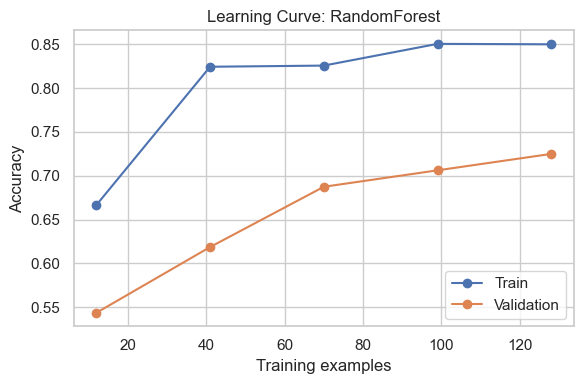

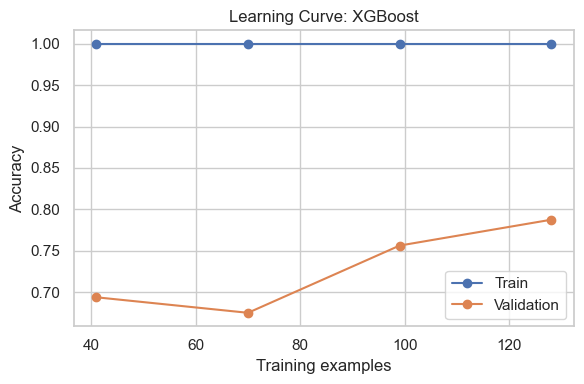

Learning curve failed for ANN: list index out of range


In [51]:
# Learning curves per model (may be slow)
from sklearn.model_selection import learning_curve
X_train_use = globals().get('X_train_robust', globals().get('X_train'))
y_train_use = globals().get('y_train')
if X_train_use is None or y_train_use is None:
    print("X_train / y_train not found.")
else:
    for name, model in models.items():
        try:
            train_sizes, train_scores, val_scores = learning_curve(model, X_train_use, y_train_use, cv=5, n_jobs=-1, train_sizes=np.linspace(0.1,1.0,5), scoring='accuracy')
            plt.figure(figsize=(6,4))
            plt.plot(train_sizes, train_scores.mean(axis=1), 'o-', label='Train')
            plt.plot(train_sizes, val_scores.mean(axis=1), 'o-', label='Validation')
            plt.title(f'Learning Curve: {name}')
            plt.xlabel('Training examples'); plt.ylabel('Accuracy'); plt.legend(); plt.tight_layout(); plt.show()
        except Exception as e:
            print(f"Learning curve failed for {name}: {e}")

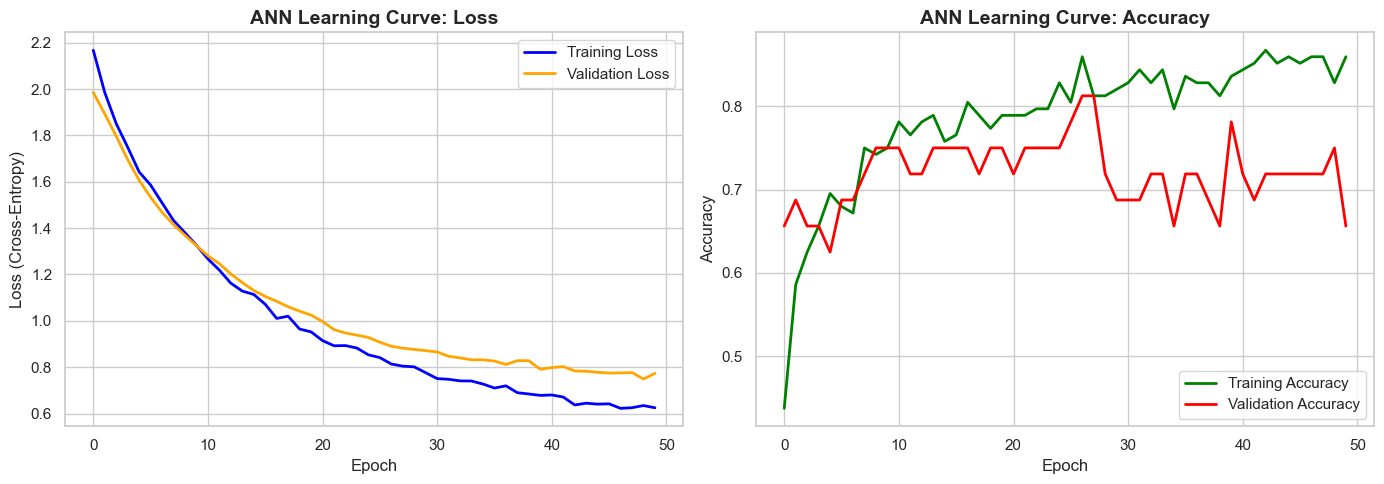

In [52]:
# 3. Plot the Learning Curves (Loss & Accuracy)
# ==========================================
# Set visual style
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Plot 1: Loss Curve ---
axes[0].plot(history.history['loss'], label='Training Loss', color='blue', linewidth=2)
axes[0].plot(history.history['val_loss'], label='Validation Loss', color='orange', linewidth=2)
axes[0].set_title('ANN Learning Curve: Loss', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss (Cross-Entropy)', fontsize=12)
axes[0].legend(loc='upper right')

# --- Plot 2: Accuracy Curve ---
axes[1].plot(history.history['accuracy'], label='Training Accuracy', color='green', linewidth=2)
axes[1].plot(history.history['val_accuracy'], label='Validation Accuracy', color='red', linewidth=2)
axes[1].set_title('ANN Learning Curve: Accuracy', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Accuracy', fontsize=12)
axes[1].legend(loc='lower right')

plt.tight_layout()

# (Optional) Save the plot as an image to use in presentations
# plt.savefig('ann_learning_curves.png', dpi=300)

plt.show()

### ROC Curve

Skipping ANN: no `predict_proba` or `decision_function`.


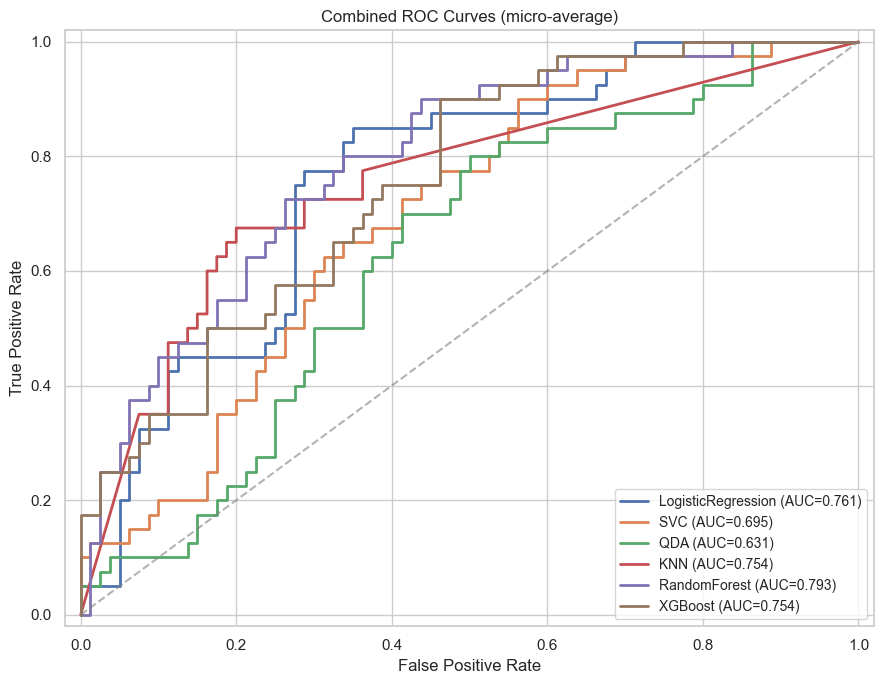

In [53]:
# Combined ROC curves (micro-average) for all models in `results`
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

# collect models
models = {}
if 'results' in globals():
    for name, info in results.items():
        model = info['model'] if isinstance(info, dict) and 'model' in info else info
        models[name] = model
else:
    raise RuntimeError("`results` not found in namespace.")

# test data (prefer scaled if available)
X_test_use = globals().get('X_test_scaled', globals().get('X_test'))
y_test_use = globals().get('y_test')
if X_test_use is None or y_test_use is None:
    raise RuntimeError("`X_test` / `y_test` not found. Define them before running this cell.")

# binarize labels for multiclass micro-average
classes = np.unique(y_test_use)
y_bin = label_binarize(y_test_use, classes=classes)

plt.figure(figsize=(9,7))
sns.set_style("whitegrid")

for name, model in models.items():
    try:
        if hasattr(model, 'predict_proba'):
            y_score = model.predict_proba(X_test_use)
        elif hasattr(model, 'decision_function'):
            y_score = model.decision_function(X_test_use)
            if y_score.ndim == 1:
                y_score = np.vstack([1 - y_score, y_score]).T
        else:
            print(f"Skipping {name}: no `predict_proba` or `decision_function`.")
            continue

        fpr, tpr, _ = roc_curve(y_bin.ravel(), y_score.ravel())
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, lw=2, label=f"{name} (AUC={roc_auc:.3f})")
    except Exception as e:
        print(f"Error for {name}: {e}")

plt.plot([0,1], [0,1], linestyle='--', color='gray', alpha=0.6)
plt.xlim([-0.02,1.02]); plt.ylim([-0.02,1.02])
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('Combined ROC Curves (micro-average)')
plt.legend(loc='lower right', fontsize='small')
plt.tight_layout()
plt.show()

## Feature Important

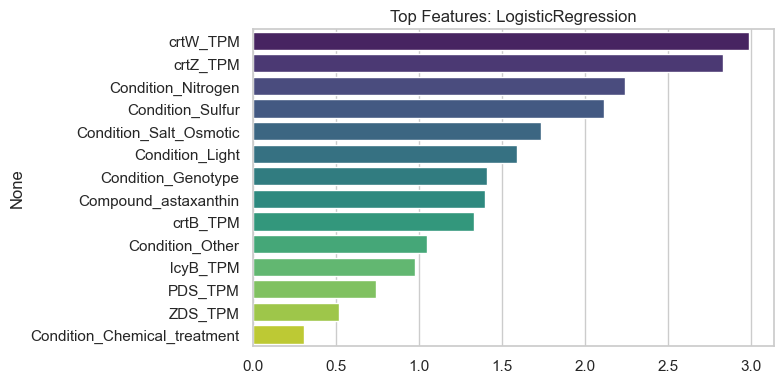

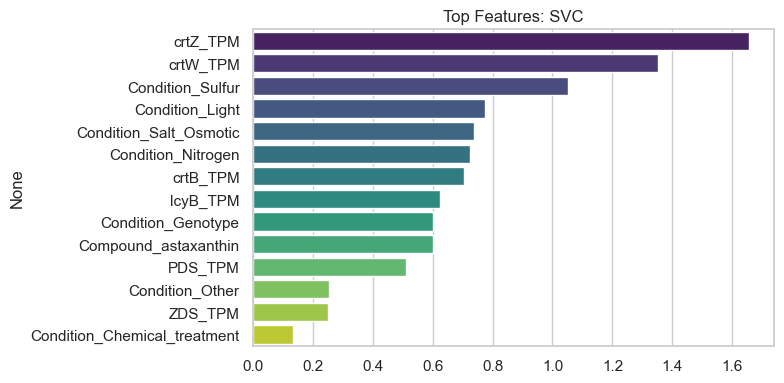

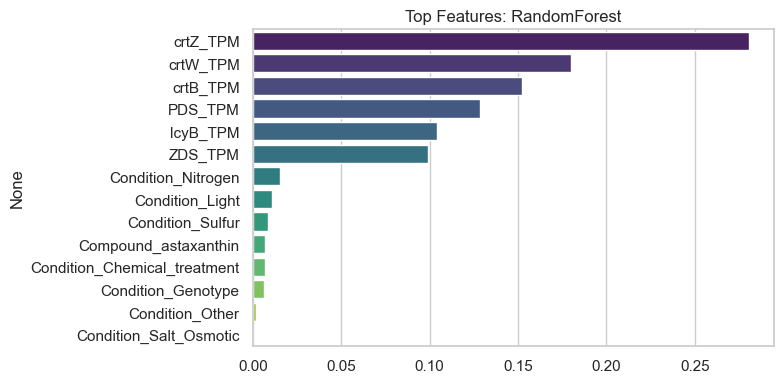

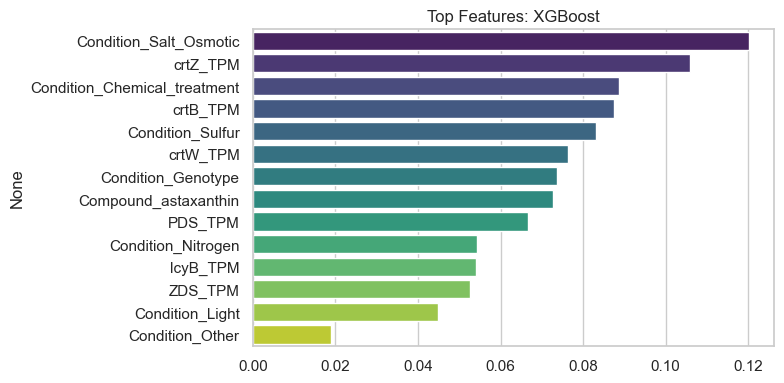

In [54]:
# Feature importances
feature_names = None
if 'X_train' in globals() and hasattr(X_train, 'columns'):
    feature_names = X_train.columns
elif 'X_encoded' in globals() and hasattr(X_encoded, 'columns'):
    feature_names = X_encoded.columns

for name, model in models.items():
    try:
        if hasattr(model, 'feature_importances_'):
            imp = model.feature_importances_
        elif hasattr(model, 'coef_'):
            imp = np.abs(model.coef_).mean(axis=0) if model.coef_.ndim>1 else np.abs(model.coef_)
        else:
            continue
        if feature_names is None:
            feature_names = [f'F{i}' for i in range(len(imp))]
        imp_df = pd.Series(imp, index=feature_names).sort_values(ascending=False).head(30)
        plt.figure(figsize=(8,4))
        sns.barplot(x=imp_df.values, y=imp_df.index, palette='viridis')
        plt.title(f'Top Features: {name}')
        plt.tight_layout(); plt.show()
    except Exception as e:
        print(f"Feature importances not available for {name}: {e}")